# Fase 2 — Clusterização: Candidatos a Deputado Federal Nordeste 2026 (TSE)

## Pergunta de negócio

> **Existem perfis demográfico-sociais distintos entre os candidatos, nas Eleições 2026? Combinando idade, escolaridade e patrimônio declarado, os candidatos se agrupam em segmentos claramente diferentes — e, se sim, como esses segmentos se distribuem em termos de gênero, cor/raça e estado civil?**

Para responder isso com K-Means, separamos as variáveis em dois papéis:

- **Variáveis-driver** (entram na conta de distância, definem os clusters): idade, escolaridade e patrimônio declarado.
- **Variáveis de perfil** (não entram no modelo — descrevem os clusters depois de prontos): `DS_GENERO`, `DS_COR_RACA`, `DS_ESTADO_CIVIL`.

> `DS_SIT_TOT_TURNO` (situação eleitoral — eleito ou não) fica de fora por enquanto: a eleição de 2026 ainda não aconteceu, então essa coluna vem toda nula nesta base. Assim que o resultado sair, vale voltar aqui e cruzar os clusters com quem foi eleito.

Essa separação importa: jogar categóricas como gênero/raça direto numa distância Euclidiana exigiria codificação cuidadosa (fora do escopo desta primeira versão). Em vez disso, os grupos nascem de 3 variáveis contínuas/ordinais bem comportadas, e o "perfil demográfico-social" completo — que é o que a pergunta pede — aparece na leitura dos clusters, não na formação deles.

**Este notebook cobre a Parte 1 (K-Means)**, em **duas rodadas de propósito**, pra mostrar por que escolha de variável e escolha de métrica importam:

1. **Versão 1**: exatamente como fizemos na primeira tentativa — escolaridade entra como o código bruto do TSE, seleção de `k` só com cotovelo + silhouette.
2. **Versão 2**: escolaridade recodificada como variável intervalar, e mais duas métricas (Davies-Bouldin, Calinski-Harabasz) apoiando a escolha de `k`.

O algoritmo **Bisecting K-Means** foi implementado e comparado com o K-Means tradicional para validar a estabilidade da partição.

Parte do arquivo salvo pela **Fase 0** (`00_preparacao_dados.ipynb`).

## Configuração

In [1]:
CARGO = "DEPUTADO FEDERAL"
UF = 'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE'
ANO_ELEICAO = 2026

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, BisectingKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

SEMENTE = 42
np.random.seed(SEMENTE)  # reprodutibilidade defensiva — o KMeans já usa random_state próprio,
                          # mas fixar a semente global evita surpresa se alguém adicionar
                          # outro trecho aleatório (amostragem, shuffle, etc.) mais adiante.

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo = f"dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv"

df = pd.read_csv(arquivo)
print(f"Carregado: {arquivo}  ->  {df.shape[0]} candidatos, {df.shape[1]} colunas")
df.head()

Carregado: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv  ->  2189 candidatos, 64 colunas


,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,SG_UF,SG_UE,NM_UE,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NM_URNA_CANDIDATO,NM_SOCIAL_CANDIDATO,NR_CPF_CANDIDATO,DS_EMAIL,CD_SITUACAO_CANDIDATURA,DS_SITUACAO_CANDIDATURA,TP_AGREMIACAO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,NR_FEDERACAO,NM_FEDERACAO,SG_FEDERACAO,DS_COMPOSICAO_FEDERACAO,SQ_COLIGACAO,NM_COLIGACAO,DS_COMPOSICAO_COLIGACAO,SG_UF_NASCIMENTO,DT_NASCIMENTO,NR_TITULO_ELEITORAL_CANDIDATO,CD_GENERO,DS_GENERO,CD_GRAU_INSTRUCAO,DS_GRAU_INSTRUCAO,CD_ESTADO_CIVIL,DS_ESTADO_CIVIL,CD_COR_RACA,DS_COR_RACA,CD_OCUPACAO,DS_OCUPACAO,CD_SIT_TOT_TURNO,DS_SIT_TOT_TURNO,BENS IMÓVEIS,BENS MÓVEIS,DINHEIRO,INVESTIMENTOS RENDA FIXA,INVESTIMENTOS RENDA VARIÁVEL,OUTROS BENS,Total_Bens,Total_Bens_Log,Total_Despesas_Contratadas,Total_Despesas_Pagas,Total_Despesas_Contratadas_Log,Total_Despesas_Pagas_Log,ANOS_ESTUDO,IDADE
0,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532430,3033,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,CAROL SOUZA,#NULO,10279565488,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1991-11-10,40248081791,4,FEMININO,8,SUPERIOR COMPLETO,1,SOLTEIRO(A),2,PRETA,132,PSICÓLOGO,-1,#NULO,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,15500.00,15500.00,9.648660,9.648660,16,34
1,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532431,3030,JOSÉ GUIDO DO RÊGO SANTOS NETO,GUIDO SANTOS,#NULO,5955901442,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1985-06-07,31724561767,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,296,SERVIDOR PÚBLICO FEDERAL,-1,#NULO,0.0,0.0,45000.00,0.0,0.0,70000.0,115000.00,11.652696,14099.27,14099.27,9.553949,9.553949,16,41
2,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532432,3003,JOÃO CARLOS LIMA UCHÔA,JOÃO UCHÔA,#NULO,48288586449,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1965-02-12,5104321775,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,131,ADVOGADO,-1,#NULO,1850000.0,841018.0,77464.01,0.0,0.0,1000000.0,3768482.01,15.142183,19635.06,19635.06,9.885123,9.885123,16,61
3,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532433,3000,ANA CAROLINA BELTRÃO PEIXOTO,PROFESSORA CAROL,#NULO,2734264439,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1978-09-21,24962281775,4,FEMININO,8,SUPERIOR COMPLETO,5,VIÚVO(A),1,BRANCA,297,SERVIDOR PÚBLICO ESTADUAL,-1,#NULO,570000.0,60000.0,0.00,0.0,0.0,0.0,630000.00,13.353477,51044.66,51043.66,10.840476,10.840456,16,48
4,23/08/2026,19:30:42,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,2026-10-04,ESTADUAL,AL,AL,ALAGOAS,6,DEPUTADO FEDERAL,20002532434,3001,JOSÉ ALEX BRANDÃO SILVEIRA,ALEX BRANDÃO,#NULO,3732710424,NÃO DIVULGÁVEL,-3,#NE,PARTIDO ISOLADO,30,NOVO,PARTIDO NOVO,-1,#NULO,#NULO,#NULO,20001800111,PARTIDO ISOLADO,NOVO,AL,1981-08-03,26986421767,2,MASCULINO,8,SUPERIOR COMPLETO,3,CASADO(A),1,BRANCA,403,"CORRETOR DE IMÓVEIS, SEGUROS, TÍTULOS E VALORES",-1,#NULO,950000.0,0.0,0.00,0.0,0.0,142000.0,1092000.00,13.903522,21932.67,21932.67,9.995778,9.995778,16,45


---
# Versão 1 — a primeira tentativa

Variáveis-driver: `IDADE`, `CD_GRAU_INSTRUCAO` (código bruto do TSE, 2 a 8), `Total_Bens_Log`. Escolha de `k` só com cotovelo (WCSS) + silhouette.

### V1.1) Outliers e padronização

In [3]:
colunas_driver_v1 = ['IDADE', 'CD_GRAU_INSTRUCAO', 'Total_Bens_Log']

antes = df.shape[0]
Q1, Q3 = df['Total_Bens_Log'].quantile([0.25, 0.75])
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_cluster_v1 = df[df['Total_Bens_Log'] <= limite_superior].copy()
print(f"Removidos {antes - df_cluster_v1.shape[0]} candidatos com patrimônio extremo "
      f"(Total_Bens_Log > {limite_superior:.2f}, ~R$ {np.expm1(limite_superior):,.0f})")
print(f"Base para clusterização: {df_cluster_v1.shape[0]} candidatos")

scaler_v1 = MinMaxScaler()
X_v1 = scaler_v1.fit_transform(df_cluster_v1[colunas_driver_v1])

df_cluster_v1[colunas_driver_v1].describe()

Removidos 0 candidatos com patrimônio extremo (Total_Bens_Log > 33.00, ~R$ 214,282,354,743,395)
Base para clusterização: 2189 candidatos


,IDADE,CD_GRAU_INSTRUCAO,Total_Bens_Log
count,2189.000000,2189.000000,2189.000000
mean,48.100959,7.105984,8.092038
std,11.730534,1.295720,6.186063
min,21.000000,2.000000,0.000000
25%,40.000000,6.000000,0.000000
50%,48.000000,8.000000,11.350418
75%,56.000000,8.000000,13.199326
max,81.000000,8.000000,18.489351


### V1.2) Escolhendo k (cotovelo + silhouette)

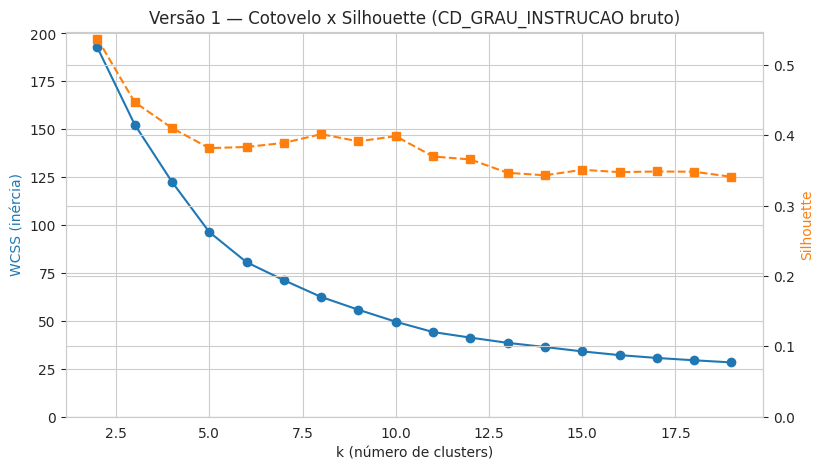

k=2  WCSS=192.663  silhouette=0.538
k=3  WCSS=152.466  silhouette=0.447
k=4  WCSS=122.566  silhouette=0.410
k=5  WCSS=96.377  silhouette=0.382
k=6  WCSS=80.614  silhouette=0.384
k=7  WCSS=71.238  silhouette=0.389
k=8  WCSS=62.490  silhouette=0.402
k=9  WCSS=55.814  silhouette=0.392
k=10  WCSS=49.564  silhouette=0.399
k=11  WCSS=44.181  silhouette=0.370
k=12  WCSS=41.277  silhouette=0.366
k=13  WCSS=38.539  silhouette=0.347
k=14  WCSS=36.365  silhouette=0.343
k=15  WCSS=34.081  silhouette=0.351
k=16  WCSS=32.147  silhouette=0.348
k=17  WCSS=30.664  silhouette=0.349
k=18  WCSS=29.443  silhouette=0.348
k=19  WCSS=28.331  silhouette=0.341


In [4]:
wcss_v1, sil_v1 = [], []
faixa_k = range(2, 20)

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X_v1)
    wcss_v1.append(km.inertia_)
    sil_v1.append(silhouette_score(X_v1, labels))

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(list(faixa_k), wcss_v1, marker='o', color='tab:blue')
ax1.set_xlabel('k (número de clusters)')
ax1.set_ylabel('WCSS (inércia)', color='tab:blue')
ax1.set_ylim(bottom=0)  # eixo começa em zero: um eixo cortado pode fazer o cotovelo parecer mais dramático do que é
ax1.set_title('Versão 1 — Cotovelo x Silhouette (CD_GRAU_INSTRUCAO bruto)')

ax2 = ax1.twinx()
ax2.plot(list(faixa_k), sil_v1, marker='s', linestyle='--', color='tab:orange')
ax2.set_ylabel('Silhouette', color='tab:orange')
ax2.set_ylim(bottom=min(0, min(sil_v1)))
plt.show()

for k, w, s in zip(faixa_k, wcss_v1, sil_v1):
    print(f"k={k}  WCSS={w:.3f}  silhouette={s:.3f}")

> Repare que o cotovelo não mostra uma quebra nítida — a curva desce suavemente, sem um "V" claro. Isso pode ser dado real (candidatos formando mais um contínuo do que grupos separados) ou pode ser efeito de tratar uma variável ordinal como se fosse intervalar. Seguimos mesmo assim com um `k` razoável, só pra completar a Versão 1 e comparar depois.

> Repare também que o silhouette score tem seu pico em k=2, e vem a ter seu segundo maior pico em k=8 e k=10.

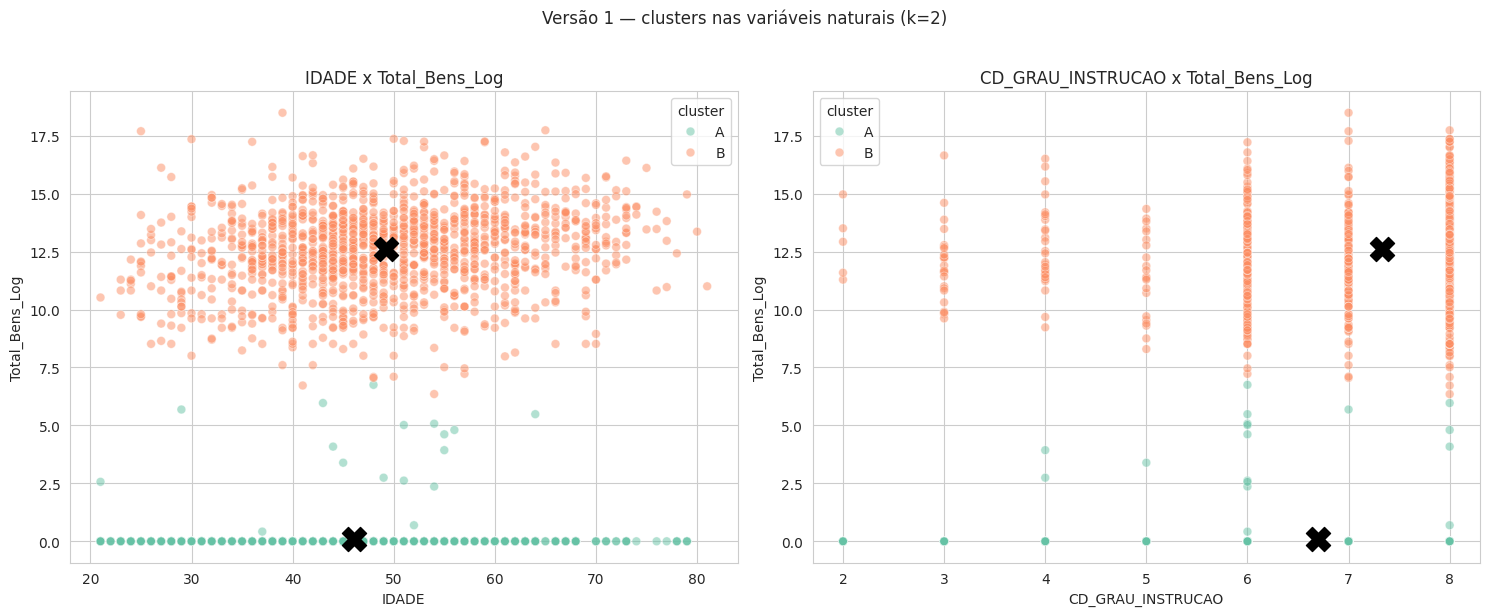

,qtd_candidatos,idade_media,instrucao_media,patrimonio_mediano
cluster,,,,
A,788,46.1,6.7,0.0
B,1401,49.2,7.3,345039.1


In [5]:
k_v1 = 2  # ajuste conforme a célula anterior, se quiser

kmeans_v1 = KMeans(n_clusters=k_v1, random_state=SEMENTE, n_init=10)
df_cluster_v1['cluster'] = kmeans_v1.fit_predict(X_v1)
df_cluster_v1['cluster'] = df_cluster_v1['cluster'].map(lambda x: chr(65 + x))

centroides_v1 = scaler_v1.inverse_transform(kmeans_v1.cluster_centers_)
df_centroides_v1 = pd.DataFrame(centroides_v1, columns=colunas_driver_v1)
df_centroides_v1.index = [chr(65 + i) for i in range(k_v1)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df_cluster_v1, x='IDADE', y='Total_Bens_Log', hue='cluster', palette='Set2', alpha=0.5, s=40, ax=axes[0])
axes[0].scatter(df_centroides_v1['IDADE'], df_centroides_v1['Total_Bens_Log'], marker='X', s=300, c='black')
axes[0].set_title('IDADE x Total_Bens_Log')

sns.scatterplot(data=df_cluster_v1, x='CD_GRAU_INSTRUCAO', y='Total_Bens_Log', hue='cluster', palette='Set2', alpha=0.5, s=40, ax=axes[1])
axes[1].scatter(df_centroides_v1['CD_GRAU_INSTRUCAO'], df_centroides_v1['Total_Bens_Log'], marker='X', s=300, c='black')
axes[1].set_title('CD_GRAU_INSTRUCAO x Total_Bens_Log')

plt.suptitle(f'Versão 1 — clusters nas variáveis naturais (k={k_v1})', y=1.02)
plt.tight_layout()
plt.show()

resumo_v1 = df_cluster_v1.groupby('cluster').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    instrucao_media=('CD_GRAU_INSTRUCAO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_v1)

---
# Versão 2 — ajustando a variável e a métrica

Dois ajustes em relação à Versão 1:

1. **Escolaridade como variável intervalar.** `CD_GRAU_INSTRUCAO` é um código **ordinal**, não intervalar: nada garante que o "salto" entre dois códigos consecutivos valha o mesmo em todos os pontos da escala (a diferença entre "lê e escreve" e "fundamental incompleto" não é comparável à diferença entre "superior incompleto" e "superior completo"). Como o K-Means calcula médias e distância Euclidiana, ele *assume* espaçamento igual — então usar o código bruto distorce essa variável. Trocamos pelo proxy padrão em pesquisa social: **anos de escolaridade equivalentes** (mesma lógica usada em censos/pesquisas domiciliares).
2. **Mais métricas para escolher `k`.** Além de WCSS e silhouette, adicionamos Davies-Bouldin e Calinski-Harabasz — quando o cotovelo é ambíguo (como foi o caso), várias métricas concordando é um sinal mais forte do que uma métrica só.

In [6]:
ANOS_ESTUDO_POR_GRAU = {
    'ANALFABETO': 0,
    'LÊ E ESCREVE': 1,
    'ENSINO FUNDAMENTAL INCOMPLETO': 4,
    'ENSINO FUNDAMENTAL COMPLETO': 8,
    'ENSINO MÉDIO INCOMPLETO': 9,
    'ENSINO MÉDIO COMPLETO': 11,
    'SUPERIOR INCOMPLETO': 13,
    'SUPERIOR COMPLETO': 16,
    # 'NÃO DIVULGÁVEL' fica de fora de propósito — não dá pra estimar anos de estudo sem essa informação
}

df['ANOS_ESTUDO'] = df['DS_GRAU_INSTRUCAO'].map(ANOS_ESTUDO_POR_GRAU)

print("Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar):", df['ANOS_ESTUDO'].isna().sum())
df[['DS_GRAU_INSTRUCAO', 'ANOS_ESTUDO']].drop_duplicates().sort_values('ANOS_ESTUDO')

Candidatos sem correspondência (NÃO DIVULGÁVEL ou similar): 0


,DS_GRAU_INSTRUCAO,ANOS_ESTUDO
97,LÊ E ESCREVE,1
15,ENSINO FUNDAMENTAL INCOMPLETO,4
38,ENSINO FUNDAMENTAL COMPLETO,8
50,ENSINO MÉDIO INCOMPLETO,9
9,ENSINO MÉDIO COMPLETO,11
20,SUPERIOR INCOMPLETO,13
0,SUPERIOR COMPLETO,16


> **Alternativa mais rigorosa (fora do escopo desta primeira versão):** distância de **Gower** — que trata variáveis ordinais, nominais e contínuas de forma nativa, sem forçar nenhuma delas a um espaçamento artificial — combinada com **K-Medoids/PAM** em vez de K-Means (Gower não permite calcular "média", só distância entre pontos reais). O Bisecting K-Means já foi implementado e validado nas seções seguintes.

### V2.1) Outliers e padronização

In [7]:
colunas_driver = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log']

antes = df.shape[0]
df_cluster = df[(df['Total_Bens_Log'] <= limite_superior) & (df['ANOS_ESTUDO'].notna())].copy()
print(f"Removidos {antes - df_cluster.shape[0]} candidatos "
      f"(patrimônio extremo acima de ~R$ {np.expm1(limite_superior):,.0f}, ou escolaridade não divulgada)")
print(f"Base para clusterização: {df_cluster.shape[0]} candidatos")

scaler = MinMaxScaler()
X = scaler.fit_transform(df_cluster[colunas_driver])

df_cluster[colunas_driver].describe()

Removidos 0 candidatos (patrimônio extremo acima de ~R$ 214,282,354,743,395, ou escolaridade não divulgada)
Base para clusterização: 2189 candidatos


,IDADE,ANOS_ESTUDO,Total_Bens_Log
count,2189.000000,2189.000000,2189.000000
mean,48.100959,13.777981,8.092038
std,11.730534,3.089915,6.186063
min,21.000000,1.000000,0.000000
25%,40.000000,11.000000,0.000000
50%,48.000000,16.000000,11.350418
75%,56.000000,16.000000,13.199326
max,81.000000,16.000000,18.489351


### V2.2) Escolhendo k (cotovelo + silhouette + Davies-Bouldin + Calinski-Harabasz)

- **Silhouette** (quanto maior, melhor).
- **Davies-Bouldin** (quanto **menor**, melhor): quão parecidos/sobrepostos os clusters são entre si.
- **Calinski-Harabasz** (quanto maior, melhor): razão entre dispersão entre clusters e dispersão dentro dos clusters.

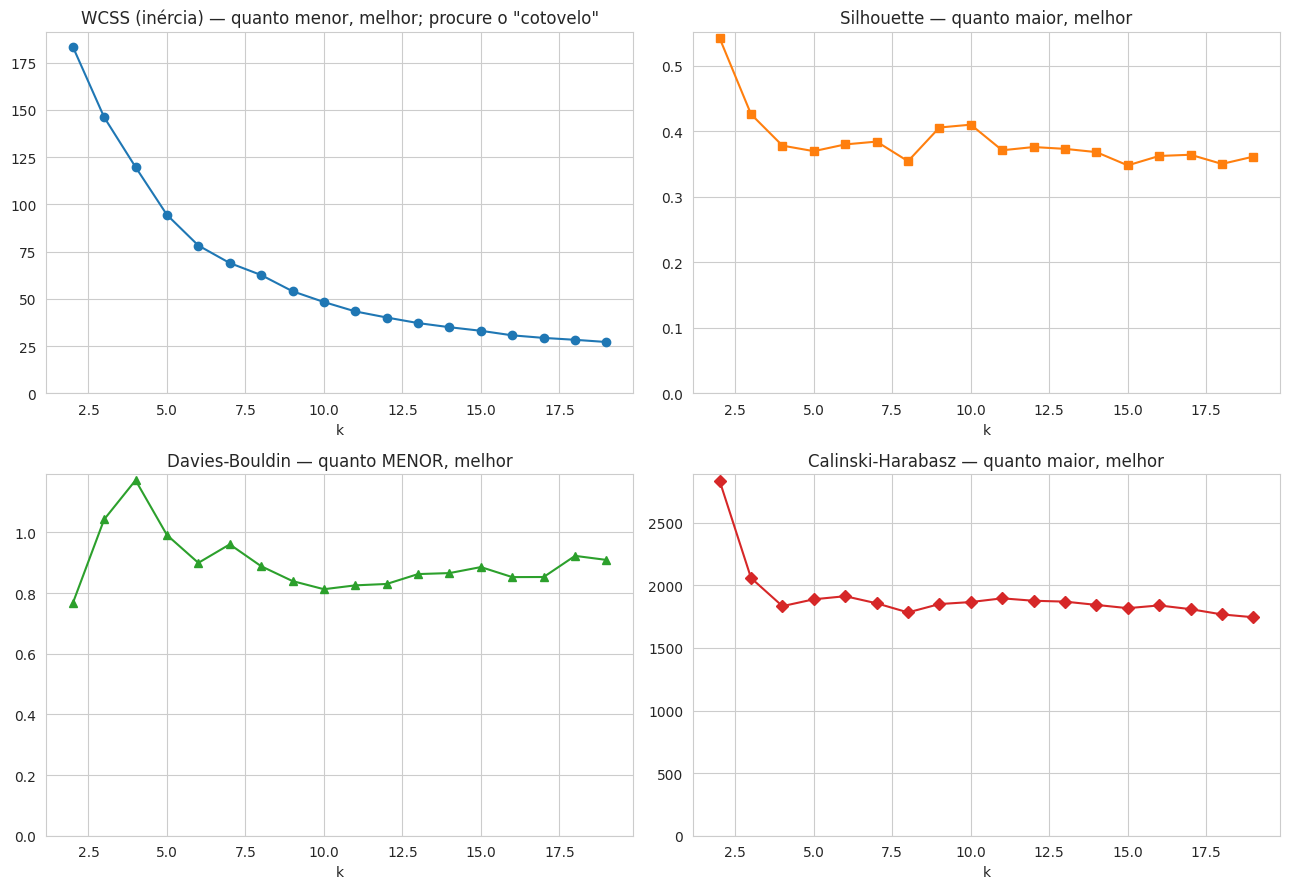

,k,wcss,silhouette,davies_bouldin,calinski_harabasz
0,2,183.535,0.542,0.767,2834.438
1,3,146.146,0.426,1.043,2058.606
2,4,119.785,0.378,1.172,1833.934
3,5,94.506,0.370,0.992,1888.655
4,6,78.292,0.380,0.900,1913.388
5,7,69.019,0.384,0.961,1856.748
6,8,62.666,0.354,0.889,1783.685
7,9,54.087,0.406,0.840,1850.608
8,10,48.383,0.410,0.813,1866.594
9,11,43.412,0.371,0.826,1896.421


In [8]:
wcss, sil, db, ch = [], [], [], []

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X, labels))
    db.append(davies_bouldin_score(X, labels))
    ch.append(calinski_harabasz_score(X, labels))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].plot(list(faixa_k), wcss, marker='o', color='tab:blue')
axes[0, 0].set_title('WCSS (inércia) — quanto menor, melhor; procure o "cotovelo"')
axes[0, 0].set_ylim(bottom=0)

axes[0, 1].plot(list(faixa_k), sil, marker='s', color='tab:orange')
axes[0, 1].set_title('Silhouette — quanto maior, melhor')
axes[0, 1].set_ylim(bottom=min(0, min(sil)))

axes[1, 0].plot(list(faixa_k), db, marker='^', color='tab:green')
axes[1, 0].set_title('Davies-Bouldin — quanto MENOR, melhor')
axes[1, 0].set_ylim(bottom=0)

axes[1, 1].plot(list(faixa_k), ch, marker='D', color='tab:red')
axes[1, 1].set_title('Calinski-Harabasz — quanto maior, melhor')
axes[1, 1].set_ylim(bottom=0)

# eixo em zero: evita que um eixo cortado exagere visualmente uma quebra que não é tão forte assim
for ax in axes.flatten():
    ax.set_xlabel('k')
    ax.grid(True)

plt.tight_layout()
plt.show()

pd.DataFrame({'k': list(faixa_k), 'wcss': wcss, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch}).round(3)

> Observamos que novamente o Silhouette score aponta para k=2, tendo seu segundo maior pico em k=9 e k=10.

> Observamos também que Davies-Bouldin aponta também para k=2, igual confirma a métrica de Calinski-Harabasz em k=2

> Porém agora podemos notar uma leve quebra no método elbow, em k=6, o que podemos deduzir que talvez dois cluster não seja a quantidade que traga real significado para nossa análise.

### V2.3) Ajustando o K-Means

Escolha o `k` cruzando as quatro métricas acima — se elas discordarem muito, prefira o `k` mais fácil de interpretar/explicar dentro da pergunta de negócio.

In [9]:
k_final = 4  # ajuste conforme a célula anterior

kmeans = KMeans(n_clusters=k_final, random_state=SEMENTE, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X)
df_cluster['cluster'] = df_cluster['cluster'].map(lambda x: chr(65 + x))

# Paleta única e fixa por cluster — reaproveitada em TODOS os gráficos daqui pra frente,
# pra cluster A ter sempre a mesma cor, em qualquer tipo de gráfico (scatter, barra, radar...).
clusters_ordenados = sorted(df_cluster['cluster'].unique())
cores_cluster = dict(zip(clusters_ordenados, sns.color_palette('Set2', n_colors=len(clusters_ordenados))))

df_cluster['cluster'].value_counts().sort_index()

cluster
A    341
B    440
C    962
D    446
Name: count, dtype: int64

In [10]:
resumo_driver = df_cluster.groupby('cluster').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_driver)

centroides_norm = kmeans.cluster_centers_
centroides_naturais = scaler.inverse_transform(centroides_norm)
df_centroides = pd.DataFrame(centroides_naturais, columns=colunas_driver)
df_centroides.index = [chr(65 + i) for i in range(k_final)]
df_centroides.index.name = 'cluster'
df_centroides.round(1)

,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster,,,,
A,341,46.3,9.6,0.0
B,440,47.9,10.8,150396.9
C,962,49.8,16.0,457357.8
D,446,46.0,15.2,0.0


,IDADE,ANOS_ESTUDO,Total_Bens_Log
cluster,,,
A,46.3,9.6,0.1
B,47.9,10.8,12.0
C,49.8,16.0,12.9
D,46.0,15.2,0.0


### Radar: todos os clusters juntos, e depois um a um

Primeiro, todos os clusters sobrepostos no mesmo radar — bom pra comparar formatos de relance. Logo abaixo, o mesmo radar **separado por cluster** — mais fácil de ler o formato de cada um sem o excesso de linhas sobrepostas. As duas versões usam os centróides **na escala padronizada (0 a 1)**, que é o que torna os 3 eixos comparáveis entre si.

In [11]:
cluster_name_map = {
    "A": "A",
    "B": "B",
    "C": "C",
    "D": "D"
    
}
df_cluster["DS_cluster"] = df_cluster["cluster"].map(cluster_name_map)
clusters_ordenados_ds = [cluster_name_map[cl] for cl in clusters_ordenados]
cores_cluster_ds = dict(zip(clusters_ordenados_ds, [cores_cluster[cl] for cl in clusters_ordenados]))

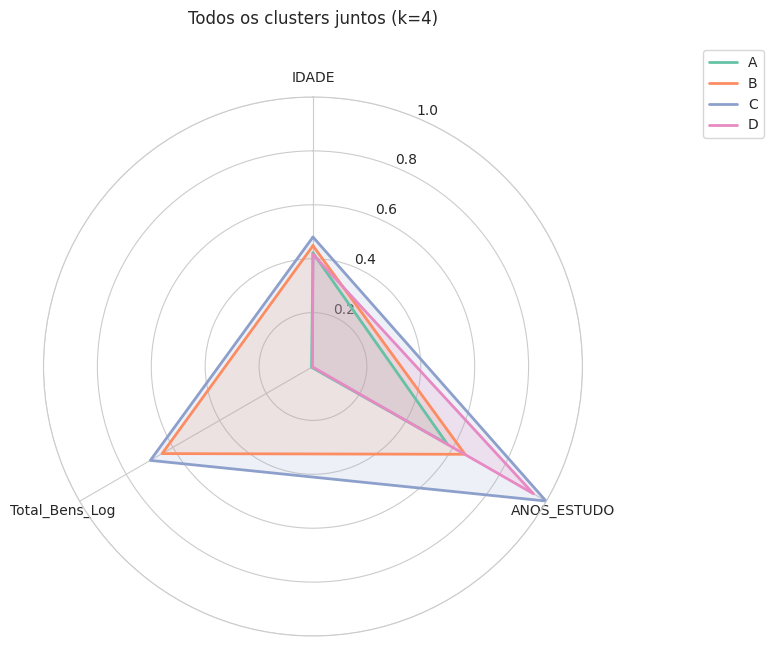

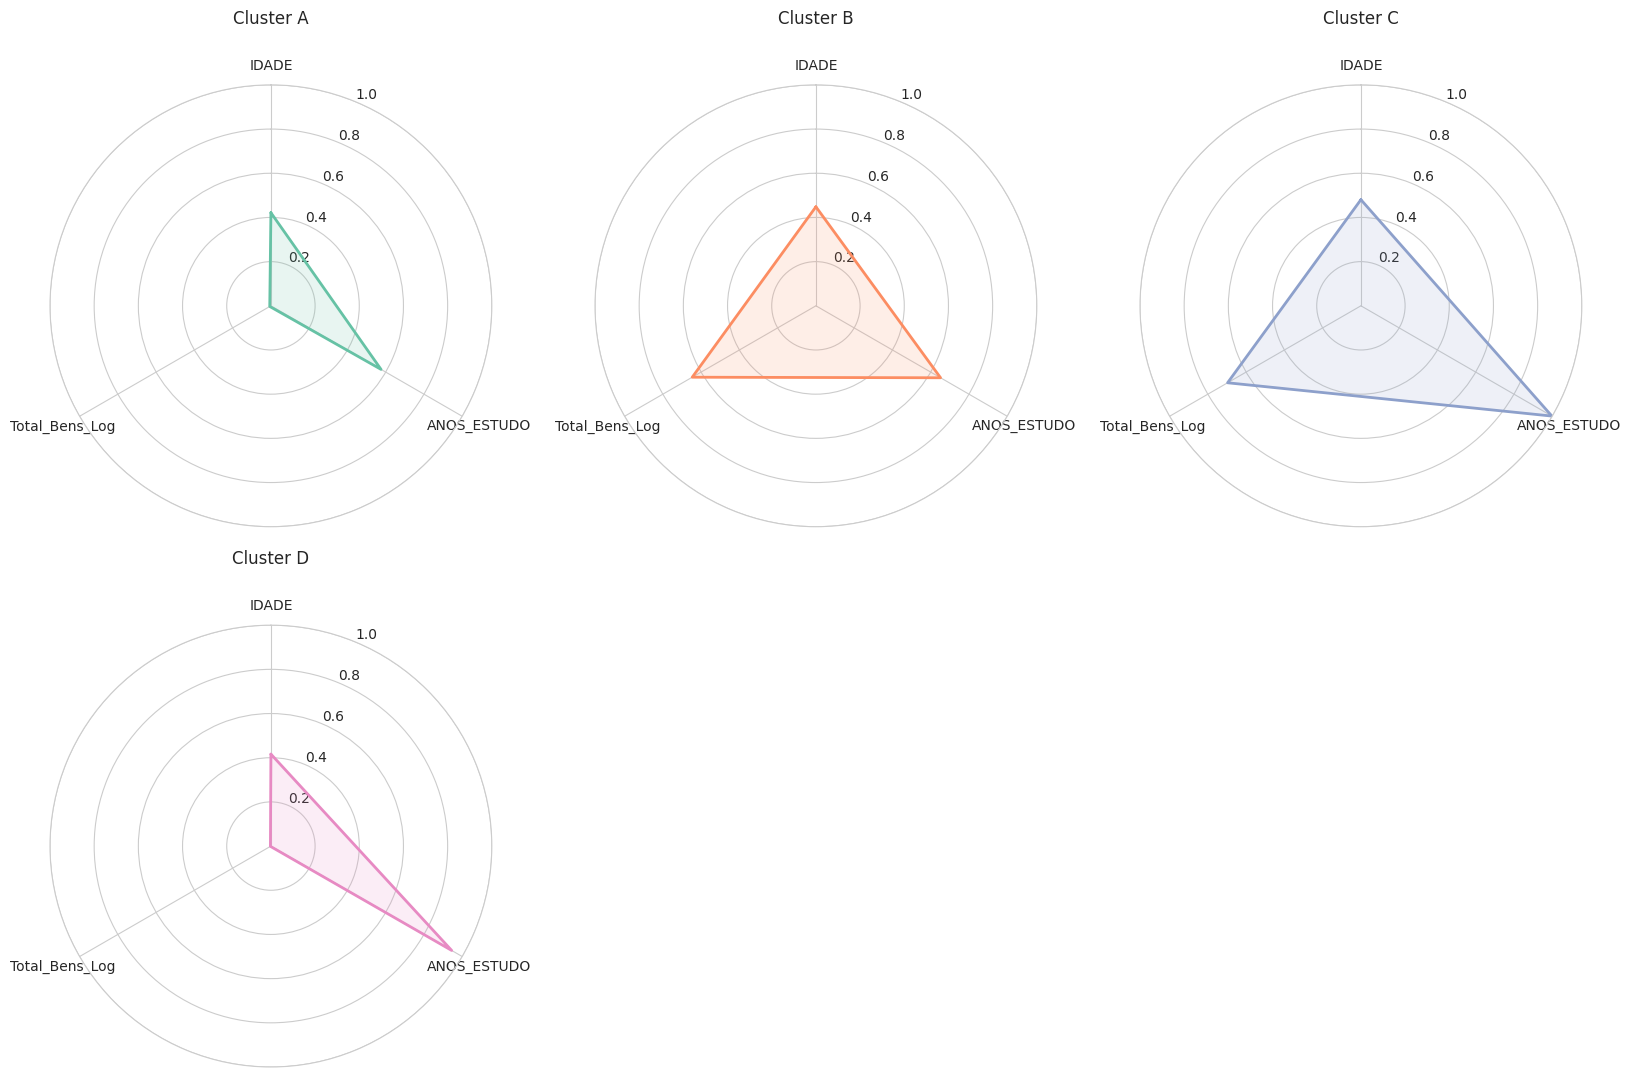

In [12]:
from math import pi

def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)
    angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)
    ax.set_ylim(0, 1)

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]
        ax.plot(angulos, valores, linewidth=2, label=labels_series[i], color=cor)
        ax.fill(angulos, valores, alpha=0.15, color=cor)

    ax.set_title(titulo, y=1.12)

# --- todos juntos ---
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
plot_radar(ax, centroides_norm, colunas_driver, clusters_ordenados_ds, cores_cluster_ds,
           f'Todos os clusters juntos (k={k_final})')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

# --- um radar por cluster ---
ncols = min(k_final, 3)
nrows = -(-k_final // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows), subplot_kw=dict(polar=True))
axes = axes.flatten() if k_final > 1 else [axes]

for i, cl in enumerate(clusters_ordenados_ds):
    plot_radar(axes[i], [centroides_norm[i]], colunas_driver, [cl], cores_cluster_ds, f'Cluster {cl}')

for j in range(len(clusters_ordenados_ds), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
## Comparando Versão 1 x Versão 2

Duas coisas pra olhar lado a lado: a **métrica de qualidade** (silhouette) e o **tamanho dos grupos** — se a distribuição de candidatos por cluster mudou bastante, é sinal de que a troca de variável/métrica realmente importou.

Versão 1 (CD_GRAU_INSTRUCAO bruto):
  Melhor k por Silhouette: 2, Silhouette score: 0.538, WCSS: 192.663
  k escolhido (cotovelo): 2, Silhouette score: 0.538, WCSS: 192.663

Versão 2 (ANOS_ESTUDO):
  Melhor k por Silhouette: 2, Silhouette score: 0.542, WCSS: 183.535
  k escolhido (múltiplas métricas): 4, Silhouette score: 0.378, WCSS: 119.785


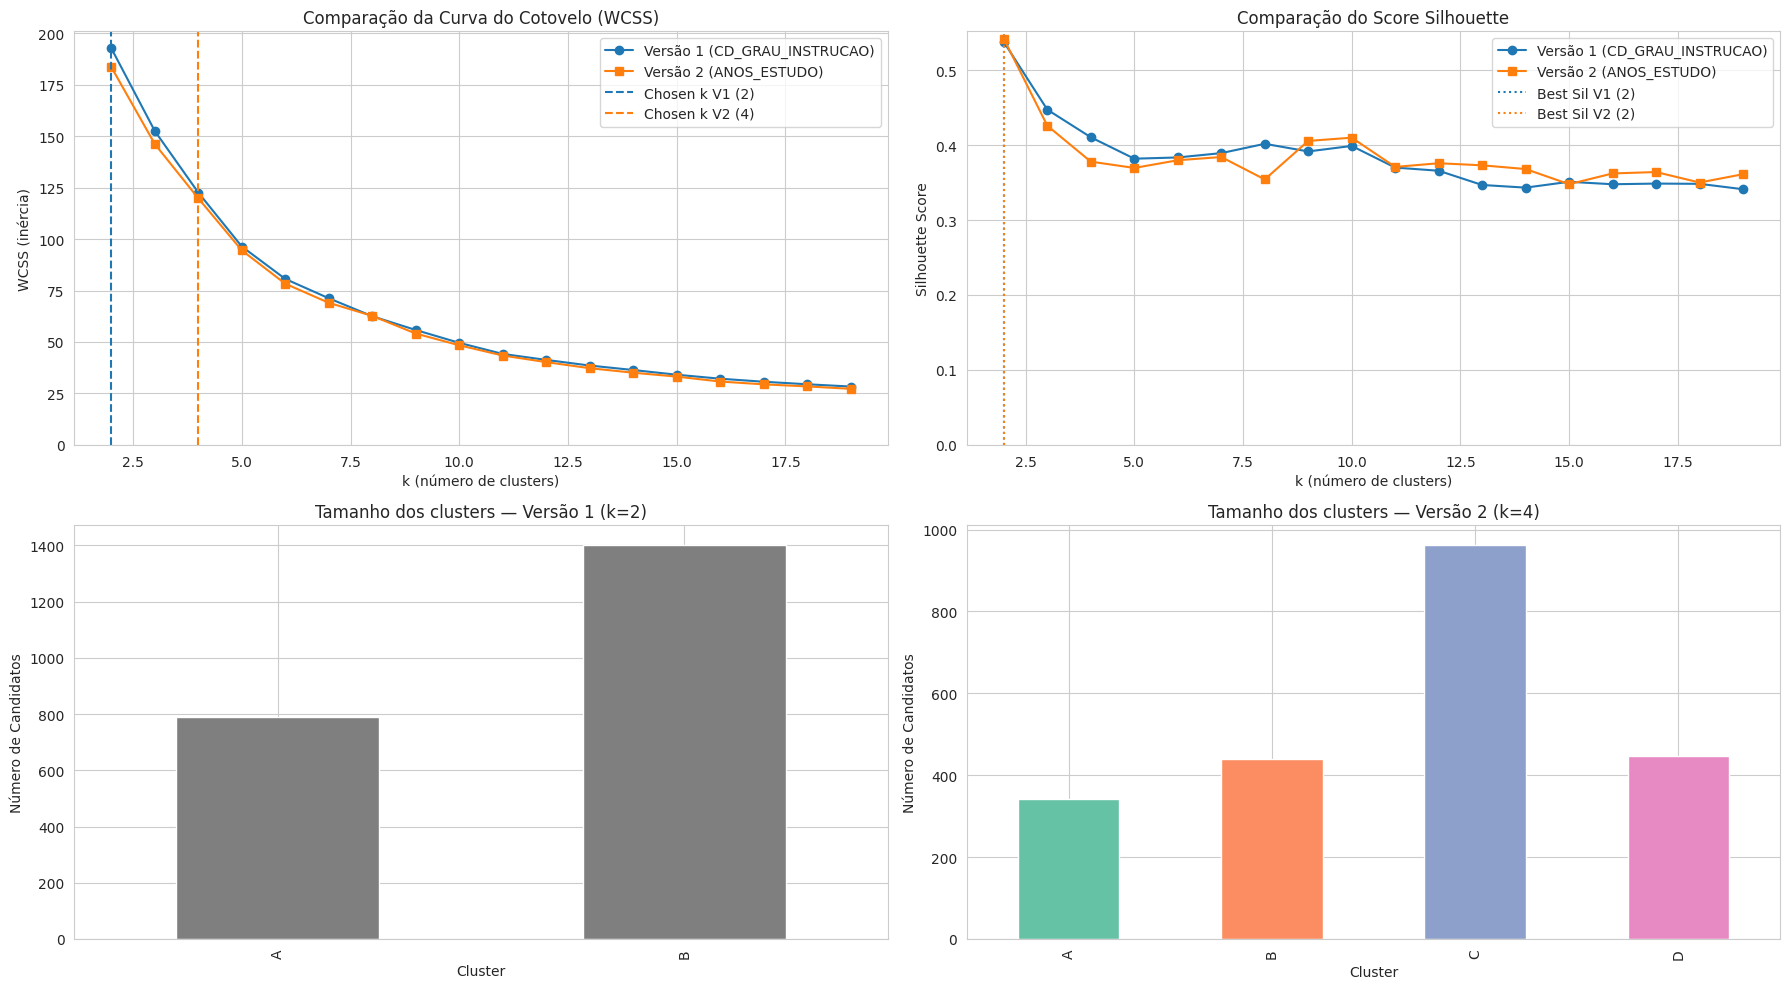

In [13]:
# Calculate the k for maximum silhouette score for Version 1
best_k_sil_v1 = faixa_k[np.argmax(sil_v1)]
max_sil_score_v1 = np.max(sil_v1)
wcss_at_best_sil_v1 = wcss_v1[list(faixa_k).index(best_k_sil_v1)]

# Calculate the k for maximum silhouette score for Version 2
best_k_sil_v2 = faixa_k[np.argmax(sil)]
max_sil_score_v2 = np.max(sil)
wcss_at_best_sil_v2 = wcss[list(faixa_k).index(best_k_sil_v2)]

print(f"Versão 1 (CD_GRAU_INSTRUCAO bruto):")
print(f"  Melhor k por Silhouette: {best_k_sil_v1}, Silhouette score: {max_sil_score_v1:.3f}, WCSS: {wcss_at_best_sil_v1:.3f}")
print(f"  k escolhido (cotovelo): {k_v1}, Silhouette score: {sil_v1[list(faixa_k).index(k_v1)]:.3f}, WCSS: {wcss_v1[list(faixa_k).index(k_v1)]:.3f}")

print(f"\nVersão 2 (ANOS_ESTUDO):")
print(f"  Melhor k por Silhouette: {best_k_sil_v2}, Silhouette score: {max_sil_score_v2:.3f}, WCSS: {wcss_at_best_sil_v2:.3f}")
print(f"  k escolhido (múltiplas métricas): {k_final}, Silhouette score: {sil[list(faixa_k).index(k_final)]:.3f}, WCSS: {wcss[list(faixa_k).index(k_final)]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(18, 10)) # Changed to 2x2 subplots

# WCSS (Elbow) comparison
axes[0, 0].plot(list(faixa_k), wcss_v1, marker='o', color='tab:blue', label='Versão 1 (CD_GRAU_INSTRUCAO)')
axes[0, 0].plot(list(faixa_k), wcss, marker='s', color='tab:orange', label='Versão 2 (ANOS_ESTUDO)')
axes[0, 0].set_title('Comparação da Curva do Cotovelo (WCSS)')
axes[0, 0].set_xlabel('k (número de clusters)')
axes[0, 0].set_ylabel('WCSS (inércia)')
axes[0, 0].set_ylim(bottom=0)
axes[0, 0].legend()
# Mark chosen k_v1 and k_final on WCSS plot
axes[0, 0].axvline(x=k_v1, color='tab:blue', linestyle='--', label=f'Chosen k V1 ({k_v1})')
axes[0, 0].axvline(x=k_final, color='tab:orange', linestyle='--', label=f'Chosen k V2 ({k_final})')
axes[0, 0].legend()

# Silhouette comparison
axes[0, 1].plot(list(faixa_k), sil_v1, marker='o', color='tab:blue', label='Versão 1 (CD_GRAU_INSTRUCAO)')
axes[0, 1].plot(list(faixa_k), sil, marker='s', color='tab:orange', label='Versão 2 (ANOS_ESTUDO)')
axes[0, 1].set_title('Comparação do Score Silhouette')
axes[0, 1].set_xlabel('k (número de clusters)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_ylim(bottom=min(0, min(min(sil), min(sil_v1))))
axes[0, 1].legend()
# Mark best k by Silhouette for both versions
axes[0, 1].axvline(x=best_k_sil_v1, color='tab:blue', linestyle=':', label=f'Best Sil V1 ({best_k_sil_v1})')
axes[0, 1].axvline(x=best_k_sil_v2, color='tab:orange', linestyle=':', label=f'Best Sil V2 ({best_k_sil_v2})')
axes[0, 1].legend()


# Cluster size comparison for Version 1
df_cluster_v1['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 0], color='tab:gray')
axes[1, 0].set_title(f'Tamanho dos clusters — Versão 1 (k={k_v1})')
axes[1, 0].set_ylabel('Número de Candidatos')
axes[1, 0].set_xlabel('Cluster')


# Cluster size comparison for Version 2
contagem_v2 = df_cluster['DS_cluster'].value_counts().sort_index()
contagem_v2.plot(kind='bar', ax=axes[1, 1], color=[cores_cluster_ds[c] for c in contagem_v2.index])
axes[1, 1].set_title(f'Tamanho dos clusters — Versão 2 (k={k_final})')
axes[1, 1].set_ylabel('Número de Candidatos')
axes[1, 1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

Versão 1 (CD_GRAU_INSTRUCAO bruto), k=2): silhouette = 0.538
Versão 2 (ANOS_ESTUDO),           k=4): silhouette = 0.378


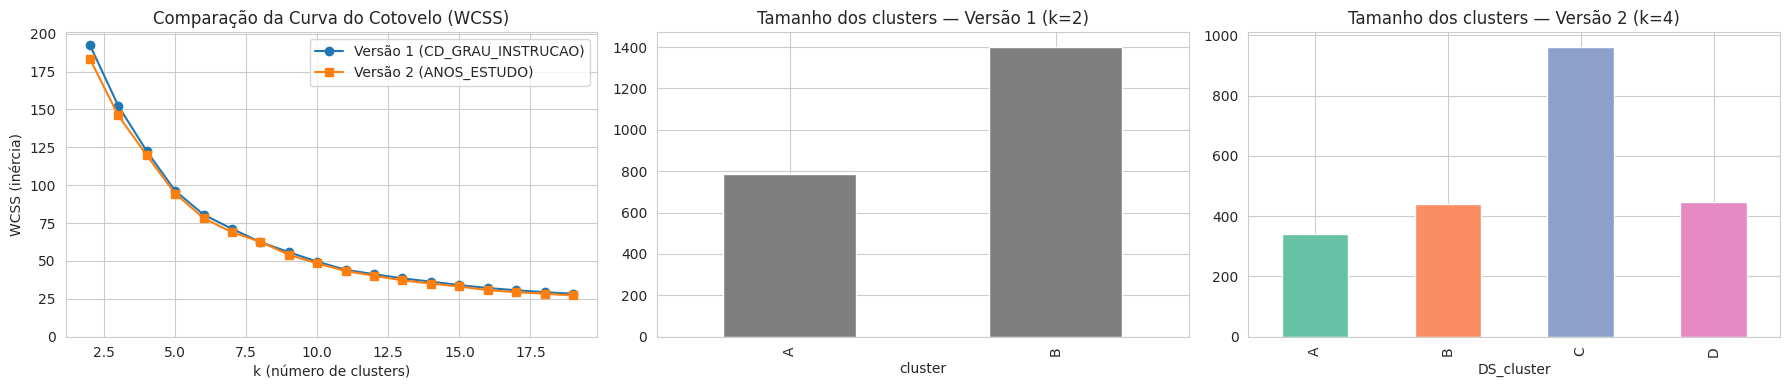

In [14]:
print(f"Versão 1 (CD_GRAU_INSTRUCAO bruto), k={k_v1}): silhouette = {sil_v1[list(faixa_k).index(k_v1)]:.3f}")
print(f"Versão 2 (ANOS_ESTUDO),           k={k_final}): silhouette = {sil[list(faixa_k).index(k_final)]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4)) # Changed to 3 subplots

# WCSS (Elbow) comparison
axes[0].plot(list(faixa_k), wcss_v1, marker='o', color='tab:blue', label='Versão 1 (CD_GRAU_INSTRUCAO)')
axes[0].plot(list(faixa_k), wcss, marker='s', color='tab:orange', label='Versão 2 (ANOS_ESTUDO)')
axes[0].set_title('Comparação da Curva do Cotovelo (WCSS)')
axes[0].set_xlabel('k (número de clusters)')
axes[0].set_ylabel('WCSS (inércia)')
axes[0].set_ylim(bottom=0)
axes[0].legend()

# Cluster size comparison for Version 1
df_cluster_v1['cluster'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='tab:gray')
axes[1].set_title(f'Tamanho dos clusters — Versão 1 (k={k_v1})')

# Cluster size comparison for Version 2
contagem_v2 = df_cluster['DS_cluster'].value_counts().sort_index()
contagem_v2.plot(kind='bar', ax=axes[2], color=[cores_cluster_ds[c] for c in contagem_v2.index])
axes[2].set_title(f'Tamanho dos clusters — Versão 2 (k={k_final})')

plt.tight_layout()
plt.show()

---
## Perfil demográfico-social de cada cluster

A partir daqui usamos a **Versão 2** (ajustada) como resultado oficial. Primeiro pelas variáveis-driver (já visto acima), agora pelas variáveis de perfil — o que responde de fato a pergunta de negócio.

### Composição demográfica de cada cluster (variáveis de perfil)

In [15]:
df_cluster["DS_cluster"]  = ' - '

In [16]:
df_cluster.loc[df_cluster['cluster']=="A", 'DS_cluster']  = 'Aa'
df_cluster.loc[df_cluster['cluster']=="B", 'DS_cluster']  = 'Bb'
df_cluster.loc[df_cluster['cluster']=="C", 'DS_cluster']  = 'Cc'
df_cluster.loc[df_cluster['cluster']=="D", 'DS_cluster']  = 'Dd'

In [17]:
df_cluster["cluster"].head()


0    D
1    C
2    C
3    C
4    C
Name: cluster, dtype: object

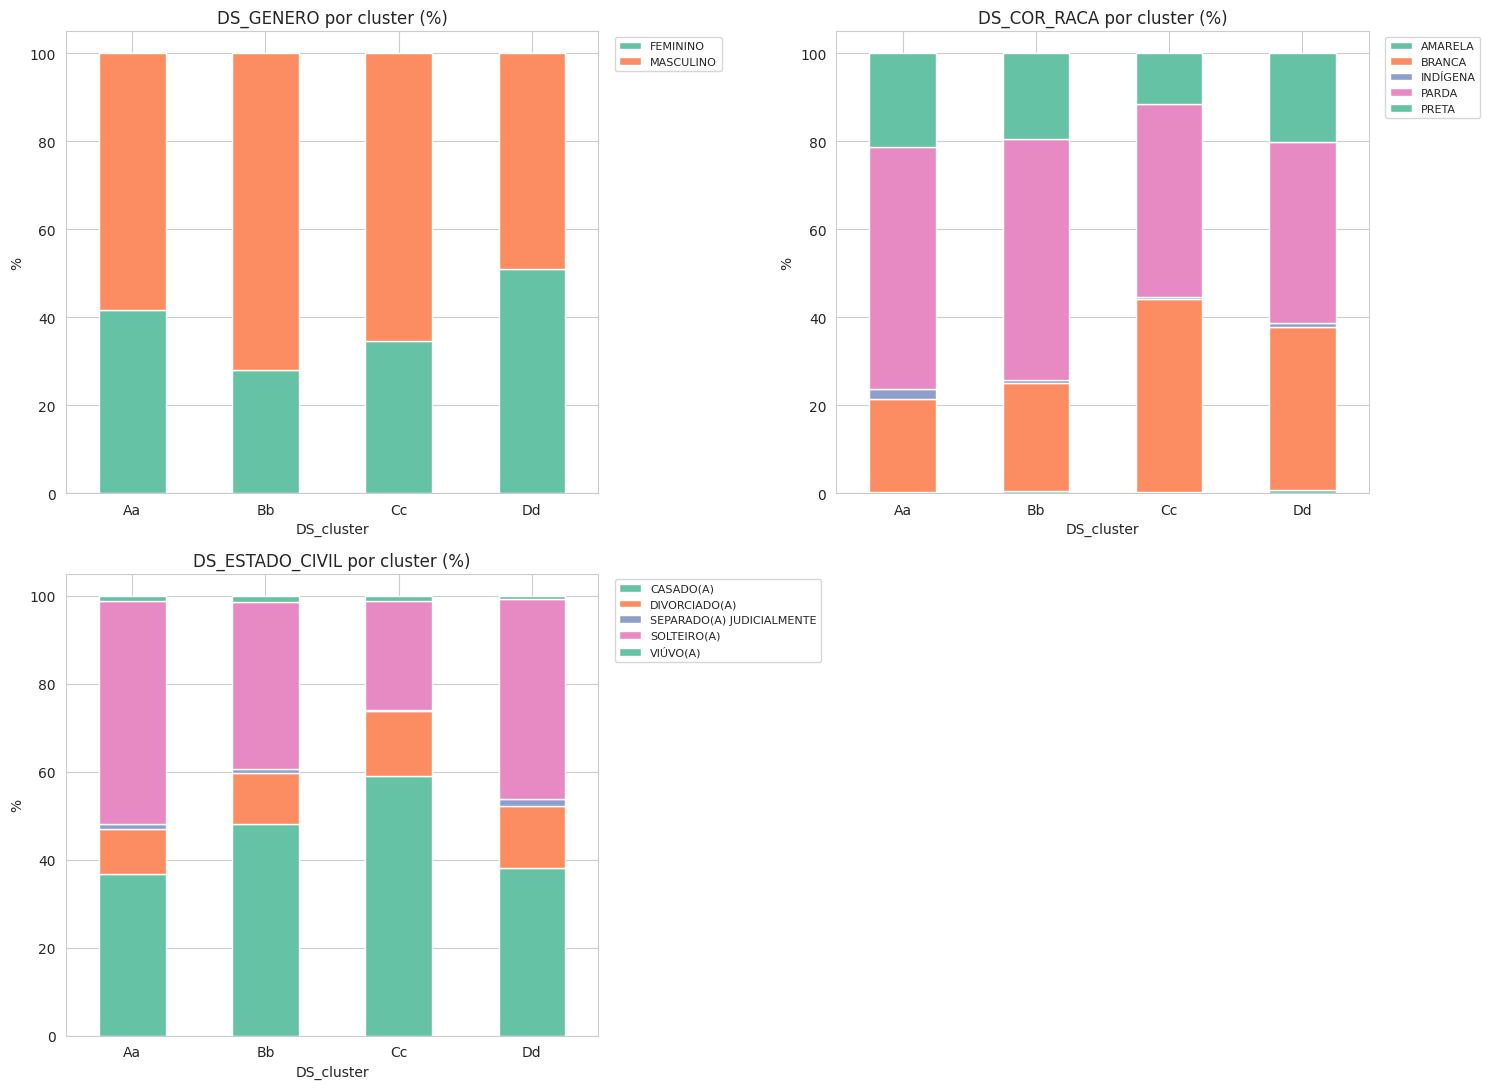

In [18]:
# DS_SIT_TOT_TURNO fica de fora por enquanto — a eleição de 2026 ainda não ocorreu,
# então essa coluna vem toda nula na base atual.
colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']
colunas_perfil = [c for c in colunas_perfil if c in df_cluster.columns]

# Re-aplica os nomes dos clusters para garantir que não haja valores ' - ' remanescentes.
cluster_name_map = {
    "A": "Aa",
    "B": "Bb",
    "C": "Cc",
    "D": "Dd"

}
df_cluster['DS_cluster'] = df_cluster['cluster'].map(cluster_name_map)

# Re-define clusters_ordenados_ds e cores_cluster_ds para garantir consistência
# com os valores (agora corrigidos) da coluna DS_cluster.
clusters_ordenados_ds = [cluster_name_map[cl] for cl in clusters_ordenados]
cores_cluster_ds = dict(zip(clusters_ordenados_ds, [cores_cluster[cl] for cl in clusters_ordenados]))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    pd.crosstab(df_cluster['DS_cluster'], df_cluster[col], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=axes[i],
        color=[cores_cluster_ds[c] for c in df_cluster['DS_cluster'].value_counts().sort_index().index] # Adiciona cores baseadas em DS_cluster
    )
    axes[i].set_title(f'{col} por cluster (%)')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Pizza: a composição de cada cluster, isoladamente

As barras acima comparam os clusters entre si — é a leitura mais rigorosa quando o que importa é comparar. As pizzas abaixo mostram a mesma informação de um jeito mais familiar pra quem só quer ver "como é o cluster A por dentro", uma variável e um cluster de cada vez.

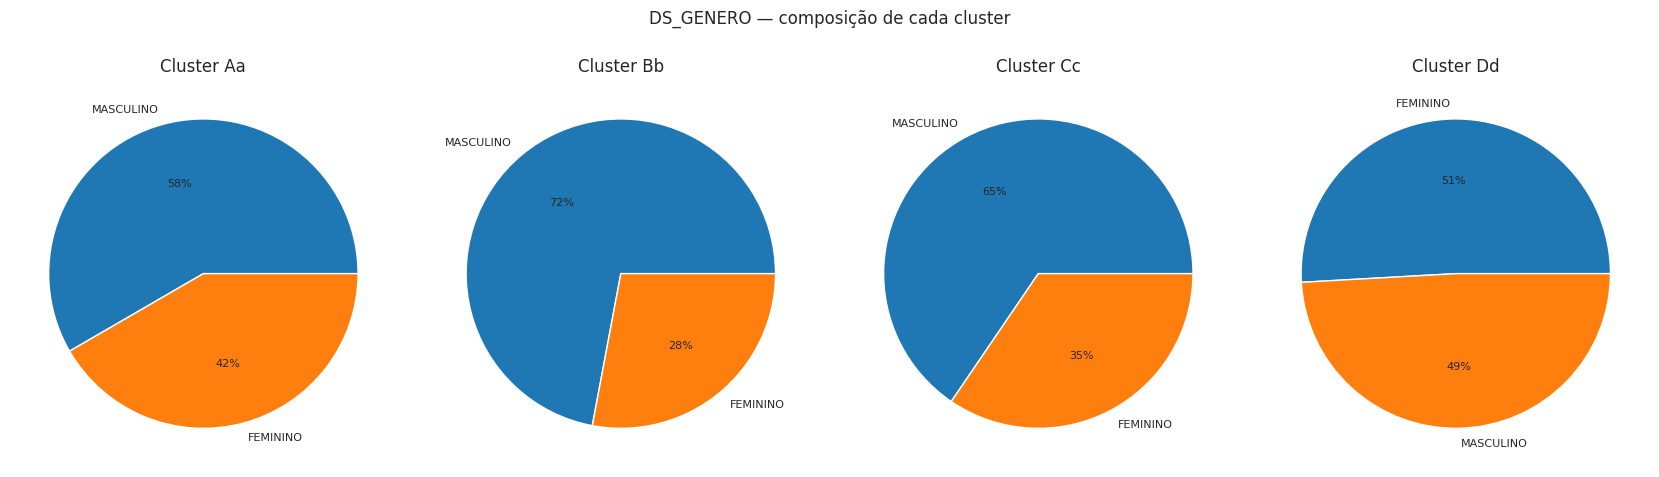

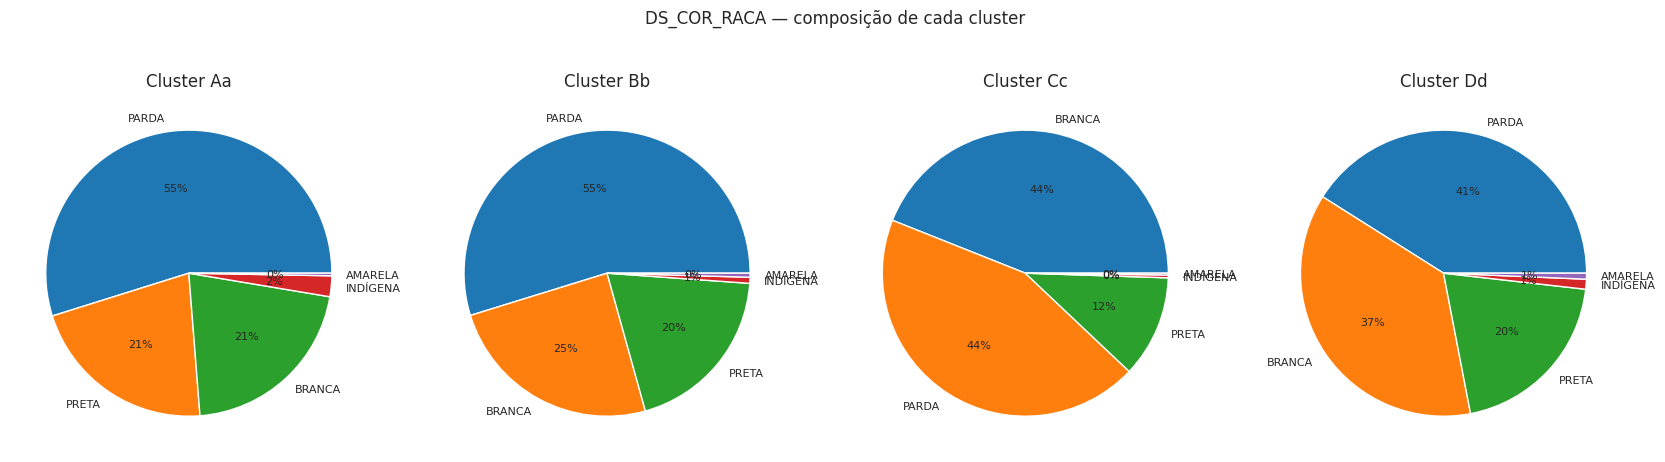

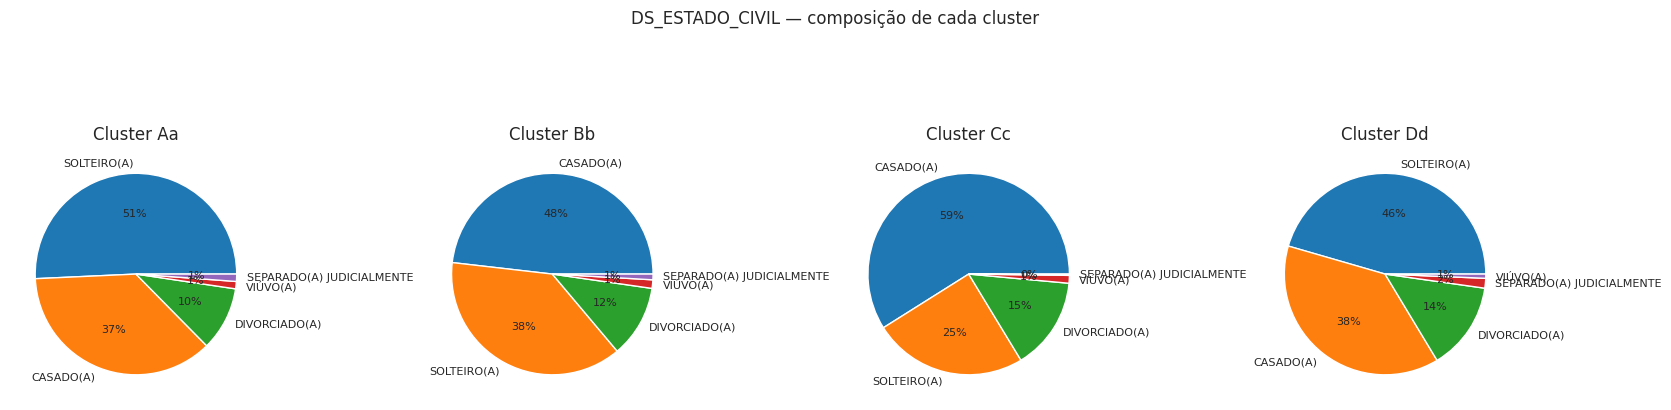

In [19]:
for col in colunas_perfil:
    fig, axes = plt.subplots(1, k_final, figsize=(4.2 * k_final, 4.5))
    if k_final == 1:
        axes = [axes]

    # Usa clusters_ordenados_ds para os títulos e na seleção
    for ax, cl in zip(axes, clusters_ordenados_ds):
        contagem = df_cluster.loc[df_cluster['DS_cluster'] == cl, col].value_counts()
        ax.pie(contagem, labels=contagem.index, autopct='%1.0f%%', textprops={'fontsize': 8})
        ax.set_title(f'Cluster {cl}')

    plt.suptitle(f'{col} — composição de cada cluster', y=1.05)
    plt.tight_layout()
    plt.show()

> Notamos que no cluster A temos mais solteiros do que nos outros clusters. Enquanto no cluster C temos mais Casados, e o cluster B e D não são tão influenciados por estado civil.

> Notamos também que no cluster C tem uma minoria de pessoas pretas e tem uma maioria de pessoas brancas e pardas. Enquanto nos restos nos cluster A e B pardos são a maioria e pretos e brancos são equilibrados. No cluster D é onde encontramos um maior equilibro entre pretos, pardos e brancos.

> Quanto aos generos, notamos que apenas o cluster D possui um equilibro entre homens e mulheres, enquanto A, B e C em sua maioria é masculino.

### Direção inversa: onde cada grupo demográfico está distribuído entre os clusters

Até aqui perguntamos "dentro do cluster X, qual a composição por gênero/cor-raça/estado civil?". Agora invertemos: **de todos os candidatos de um determinado grupo (ex.: todos os do gênero masculino), em quais clusters eles estão?** É a mesma tabela de contingência, só trocando o que normaliza — por categoria demográfica em vez de por cluster.

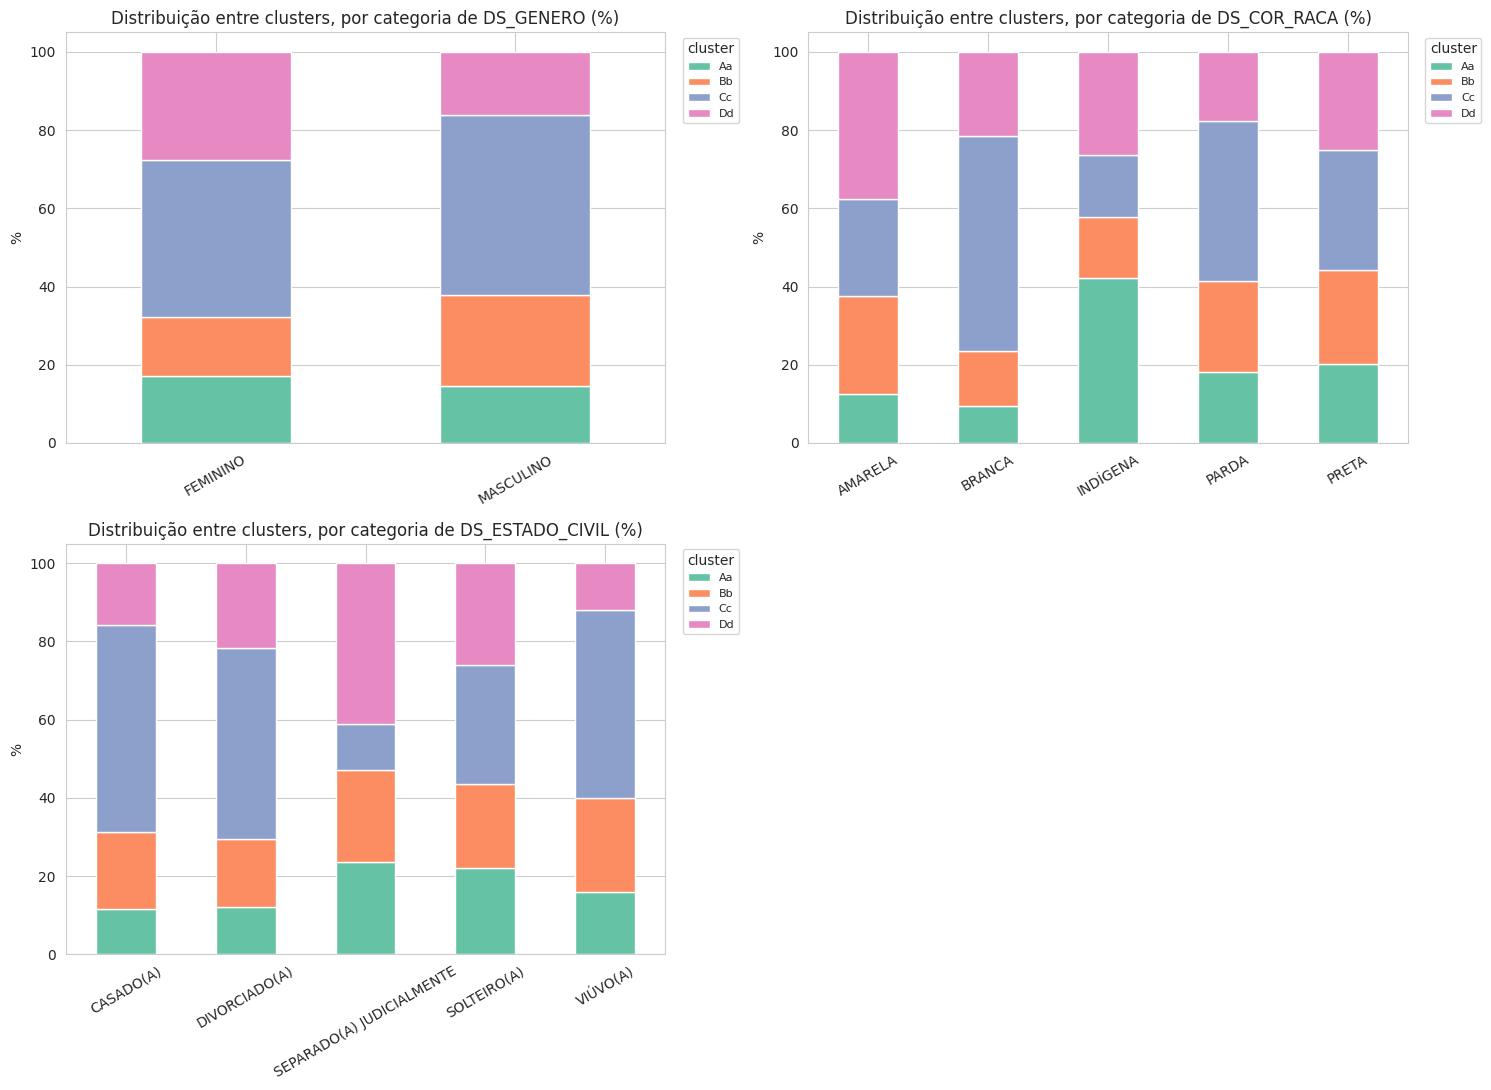

In [20]:
clusters_ordenados_ds = [cluster_name_map[cl] for cl in clusters_ordenados]
cores_cluster_ds = dict(zip(clusters_ordenados_ds, [cores_cluster[cl] for cl in clusters_ordenados]))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(colunas_perfil):
    tabela = pd.crosstab(df_cluster[col], df_cluster['DS_cluster'], normalize='index').mul(100)
    tabela = tabela[clusters_ordenados_ds]  # garante a mesma ordem de colunas de cores_cluster
    tabela.plot(kind='bar', stacked=True, ax=axes[i], color=[cores_cluster_ds[c] for c in tabela.columns])
    axes[i].set_title(f'Distribuição entre clusters, por categoria de {col} (%)')
    axes[i].set_ylabel('%')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Ocupação: Vamos analisar os clusters pela ocupação dos candidatos

Vamos analisar apenas as 10 ocupações que mais aparecem.

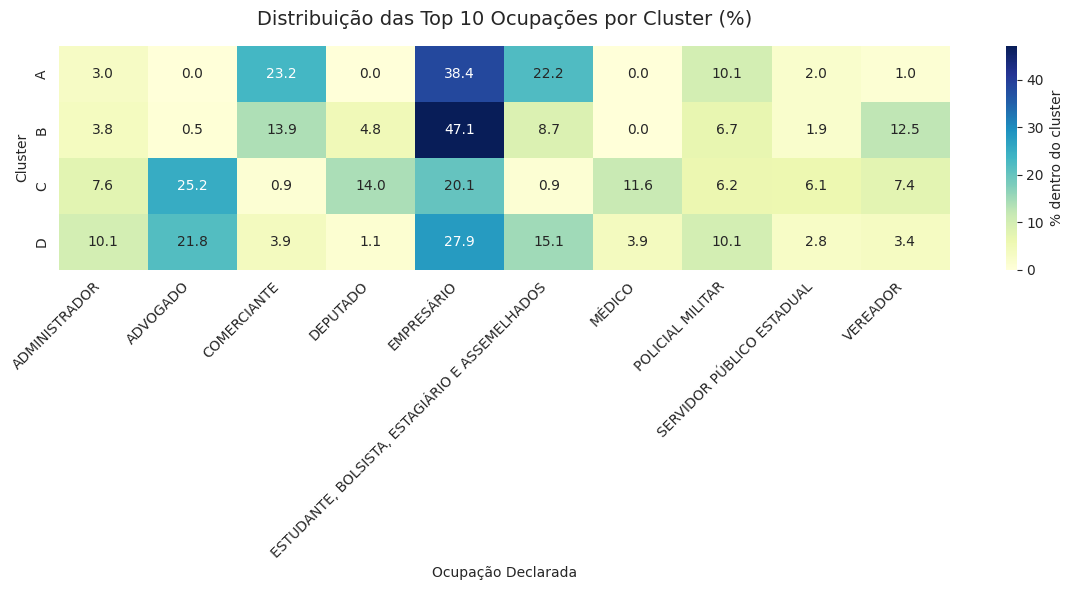

In [21]:
 # 1. Identifica as 10 ocupações mais frequentes na base
# (se quiser incluir 'OUTROS', basta tirar a condição df_cluster['DS_OCUPACAO'] != 'OUTROS')
top_10_ocupacoes = (
    df_cluster[df_cluster['DS_OCUPACAO'] != 'OUTROS']['DS_OCUPACAO']
    .value_counts()
    .head(10)
    .index
)

# 2. Filtra a base apenas com candidatos dessas 10 ocupações
df_top_ocup = df_cluster[df_cluster['DS_OCUPACAO'].isin(top_10_ocupacoes)]

# 3. Tabela de contingência percentual (% de cada ocupação DENTRO de cada cluster)
tabela_ocup = pd.crosstab(
    df_top_ocup['cluster'],
    df_top_ocup['DS_OCUPACAO'],
    normalize='index'
) * 100

# 4. Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    tabela_ocup,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': '% dentro do cluster'}
)
plt.title('Distribuição das Top 10 Ocupações por Cluster (%)', fontsize=14, pad=15)
plt.xlabel('Ocupação Declarada')
plt.ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
print("=== TOP 10 OCUPAÇÕES EM CADA CLUSTER ===")
for cl in sorted(df_cluster['cluster'].unique()):
    sub = df_cluster[df_cluster['cluster'] == cl]
    print(f"\n--- Cluster {cl} (Total: {len(sub)} candidatos) ---")

    # Mudamos apenas de head(5) para head(10)
    top_cluster = sub['DS_OCUPACAO'].value_counts(normalize=True).head(10) * 100
    for ocup, pct in top_cluster.items():
        print(f"  • {ocup}: {pct:.1f}%")


=== TOP 10 OCUPAÇÕES EM CADA CLUSTER ===

--- Cluster A (Total: 341 candidatos) ---
  • OUTROS: 25.5%
  • EMPRESÁRIO: 11.1%
  • COMERCIANTE: 6.7%
  • ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS: 6.5%
  • AGRICULTOR: 4.7%
  • DONA DE CASA: 3.8%
  • APOSENTADO (EXCETO SERVIDOR PÚBLICO): 2.9%
  • POLICIAL MILITAR: 2.9%
  • AUXILIAR DE ESCRITÓRIO E ASSEMELHADOS: 2.6%
  • CABELEIREIRO E BARBEIRO: 2.1%

--- Cluster B (Total: 440 candidatos) ---
  • EMPRESÁRIO: 22.3%
  • OUTROS: 15.0%
  • COMERCIANTE: 6.6%
  • VEREADOR: 5.9%
  • ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS: 4.1%
  • POLICIAL MILITAR: 3.2%
  • AGRICULTOR: 3.0%
  • DEPUTADO: 2.3%
  • APOSENTADO (EXCETO SERVIDOR PÚBLICO): 2.3%
  • VIGILANTE: 2.0%

--- Cluster C (Total: 962 candidatos) ---
  • ADVOGADO: 13.8%
  • EMPRESÁRIO: 11.0%
  • DEPUTADO: 7.7%
  • MÉDICO: 6.3%
  • OUTROS: 6.0%
  • ADMINISTRADOR: 4.2%
  • VEREADOR: 4.1%
  • POLICIAL MILITAR: 3.4%
  • SERVIDOR PÚBLICO ESTADUAL: 3.3%
  • PROFESSOR DE ENSINO MÉDIO: 2.8%

-

> O que podemos concluir com essa analise por ocupação: 

> Cluster A: Como tivemos 1/4 das ocupações como "OUTROS", não nos traz tanto valor direto, mas a presença de comerciantes, agricultores e estudantes ajuda a entender o perfil de escolaridade mais básica e a ausência de bens declarados.

> Cluster B: Temos quase 1/4 dos candidatos como empresários (22.3%), além de comerciantes e vereadores locais. É um grupo bem voltado para negócios e comércio, o que justifica terem um patrimônio mediano na faixa de 150 mil mesmo sem a maioria ter superior completo.

> Cluster C: Aqui temos as ocupações de maior renda e poder político: muitos advogados (quase 14%), médicos, grandes empresários e praticamente todos os deputados de mandato da base. Isso explica tanto o superior completo quanto o patrimônio mais alto de todos os grupos.

> Cluster D: Aqui temos um contraste bem legal com o cluster C, eles também têm curso superior (ou estão cursando), mas declaram zero bens. Vemos que não são políticos tradicionais nem empresários consolidados, mas sim profissionais qualificados de serviços: vários tipos de professores (médio, superior, fundamental), enfermeiros, jornalistas, servidores e advogados(provavelmente autônomos), além de estudantes. Isso bate certinho com o fato de ser o único grupo com maioria feminina e muitos solteiros — são profissionais diplomados.

---
## Respondendo à pergunta de negócio: nomeando os clusters

Esta é a etapa mais importante de toda a análise — é aqui que o K-Means (que só enxerga números) vira uma resposta que faz sentido pra gente. Três ferramentas de apoio, dos números pro nome:

1. **Ficha técnica**: uma tabela única por cluster, juntando drivers e perfil.
2. **O que destaca cada cluster**: um heatmap mostrando só o que foge da média geral — o "diferencial" de cada grupo.
3. **Rascunho automático**: um parágrafo gerado a partir da ficha técnica, pra vocês editarem em vez de escreverem do zero.

### 1) Ficha técnica por cluster

In [23]:
ficha = df_cluster.groupby('cluster').agg(
    qtd=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
ficha['pct_do_total'] = (ficha['qtd'] / ficha['qtd'].sum() * 100).round(1)

for col in colunas_perfil:
    ficha[f'{col}_predominante'] = df_cluster.groupby('cluster')[col].agg(lambda s: s.mode().iat[0])
    ficha[f'{col}_pct'] = df_cluster.groupby('cluster')[col].apply(
        lambda s: (s == s.mode().iat[0]).mean() * 100
    ).round(1)

ficha

,qtd,idade_media,anos_estudo_medio,patrimonio_mediano,pct_do_total,DS_GENERO_predominante,DS_GENERO_pct,DS_COR_RACA_predominante,DS_COR_RACA_pct,DS_ESTADO_CIVIL_predominante,DS_ESTADO_CIVIL_pct
cluster,,,,,,,,,,,
A,341,46.3,9.6,0.0,15.6,MASCULINO,58.4,PARDA,54.8,SOLTEIRO(A),50.7
B,440,47.9,10.8,150396.9,20.1,MASCULINO,72.0,PARDA,54.8,CASADO(A),48.2
C,962,49.8,16.0,457357.8,43.9,MASCULINO,65.5,BRANCA,44.0,CASADO(A),58.9
D,446,46.0,15.2,0.0,20.4,FEMININO,50.9,PARDA,41.0,SOLTEIRO(A),45.5


### 2) O que destaca cada cluster (desvio em relação à média geral)

Quanto mais forte a cor (positiva ou negativa), mais aquele cluster se afasta da média geral de candidatos naquela variável — é isso que normalmente vira o "nome" do cluster.

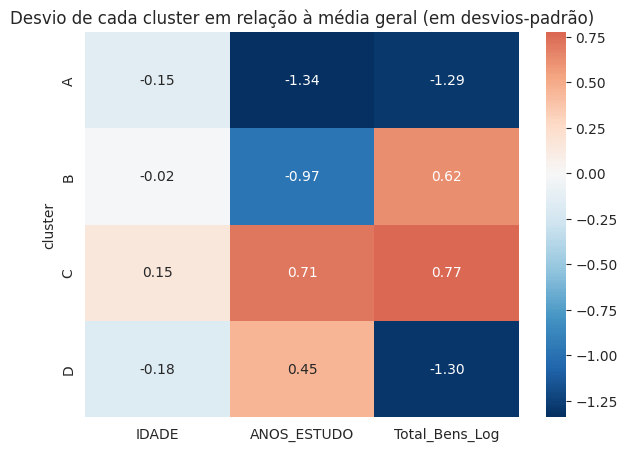

In [24]:
medias_gerais = df_cluster[colunas_driver].mean()
desvios_gerais = df_cluster[colunas_driver].std()
medias_cluster = df_cluster.groupby('cluster')[colunas_driver].mean()

zscore_cluster = (medias_cluster - medias_gerais) / desvios_gerais

plt.figure(figsize=(7, 1 + k_final))
sns.heatmap(zscore_cluster, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Desvio de cada cluster em relação à média geral (em desvios-padrão)')
plt.xlabel('')
plt.ylabel('cluster')
plt.show()

### 3) Rascunho automático

In [25]:
for cl in clusters_ordenados:
    linha = ficha.loc[cl]
    print(f"Cluster {cl}  ({linha['qtd']:.0f} candidatos, {linha['pct_do_total']:.0f}% do total)")
    print(f"  Idade média: {linha['idade_media']:.0f} anos | Escolaridade média: {linha['anos_estudo_medio']:.0f} anos de estudo "
          f"| Patrimônio mediano: R$ {linha['patrimonio_mediano']:,.0f}")
    for col in colunas_perfil:
        print(f"  Predominância em {col}: {linha[f'{col}_predominante']} ({linha[f'{col}_pct']:.0f}%)")
    print(f"  >> Nome sugerido: _______________________")
    print()

Cluster A  (341 candidatos, 16% do total)
  Idade média: 46 anos | Escolaridade média: 10 anos de estudo | Patrimônio mediano: R$ 0
  Predominância em DS_GENERO: MASCULINO (58%)
  Predominância em DS_COR_RACA: PARDA (55%)
  Predominância em DS_ESTADO_CIVIL: SOLTEIRO(A) (51%)
  >> Nome sugerido: _______________________

Cluster B  (440 candidatos, 20% do total)
  Idade média: 48 anos | Escolaridade média: 11 anos de estudo | Patrimônio mediano: R$ 150,397
  Predominância em DS_GENERO: MASCULINO (72%)
  Predominância em DS_COR_RACA: PARDA (55%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (48%)
  >> Nome sugerido: _______________________

Cluster C  (962 candidatos, 44% do total)
  Idade média: 50 anos | Escolaridade média: 16 anos de estudo | Patrimônio mediano: R$ 457,358
  Predominância em DS_GENERO: MASCULINO (66%)
  Predominância em DS_COR_RACA: BRANCA (44%)
  Predominância em DS_ESTADO_CIVIL: CASADO(A) (59%)
  >> Nome sugerido: _______________________

Cluster D  (446 candidatos, 

### Nomes finais dos clusters (K-Means)

Preencham com base nas três ferramentas acima:

- **Cluster A:** Base Popular
- **Cluster B:** Pequenos Empreendedores
- **Cluster C:** Elite
- **Cluster D:** Profissionais diplomados

In [26]:
cluster_name_map = {
    "A": "Base Popular",
    "B": "Pequenos Empreendedores",
    "C": "Elite",
    "D": "Profissionais diplomados"
    
}
df_cluster["DS_cluster"] = df_cluster["cluster"].map(cluster_name_map)
clusters_ordenados_ds = [cluster_name_map[cl] for cl in clusters_ordenados]
cores_cluster_ds = dict(zip(clusters_ordenados_ds, [cores_cluster[cl] for cl in clusters_ordenados]))

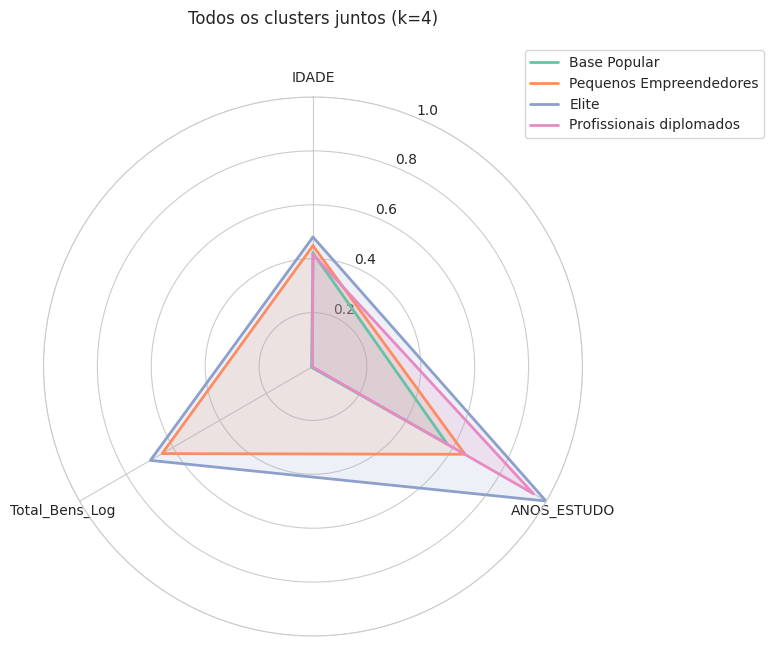

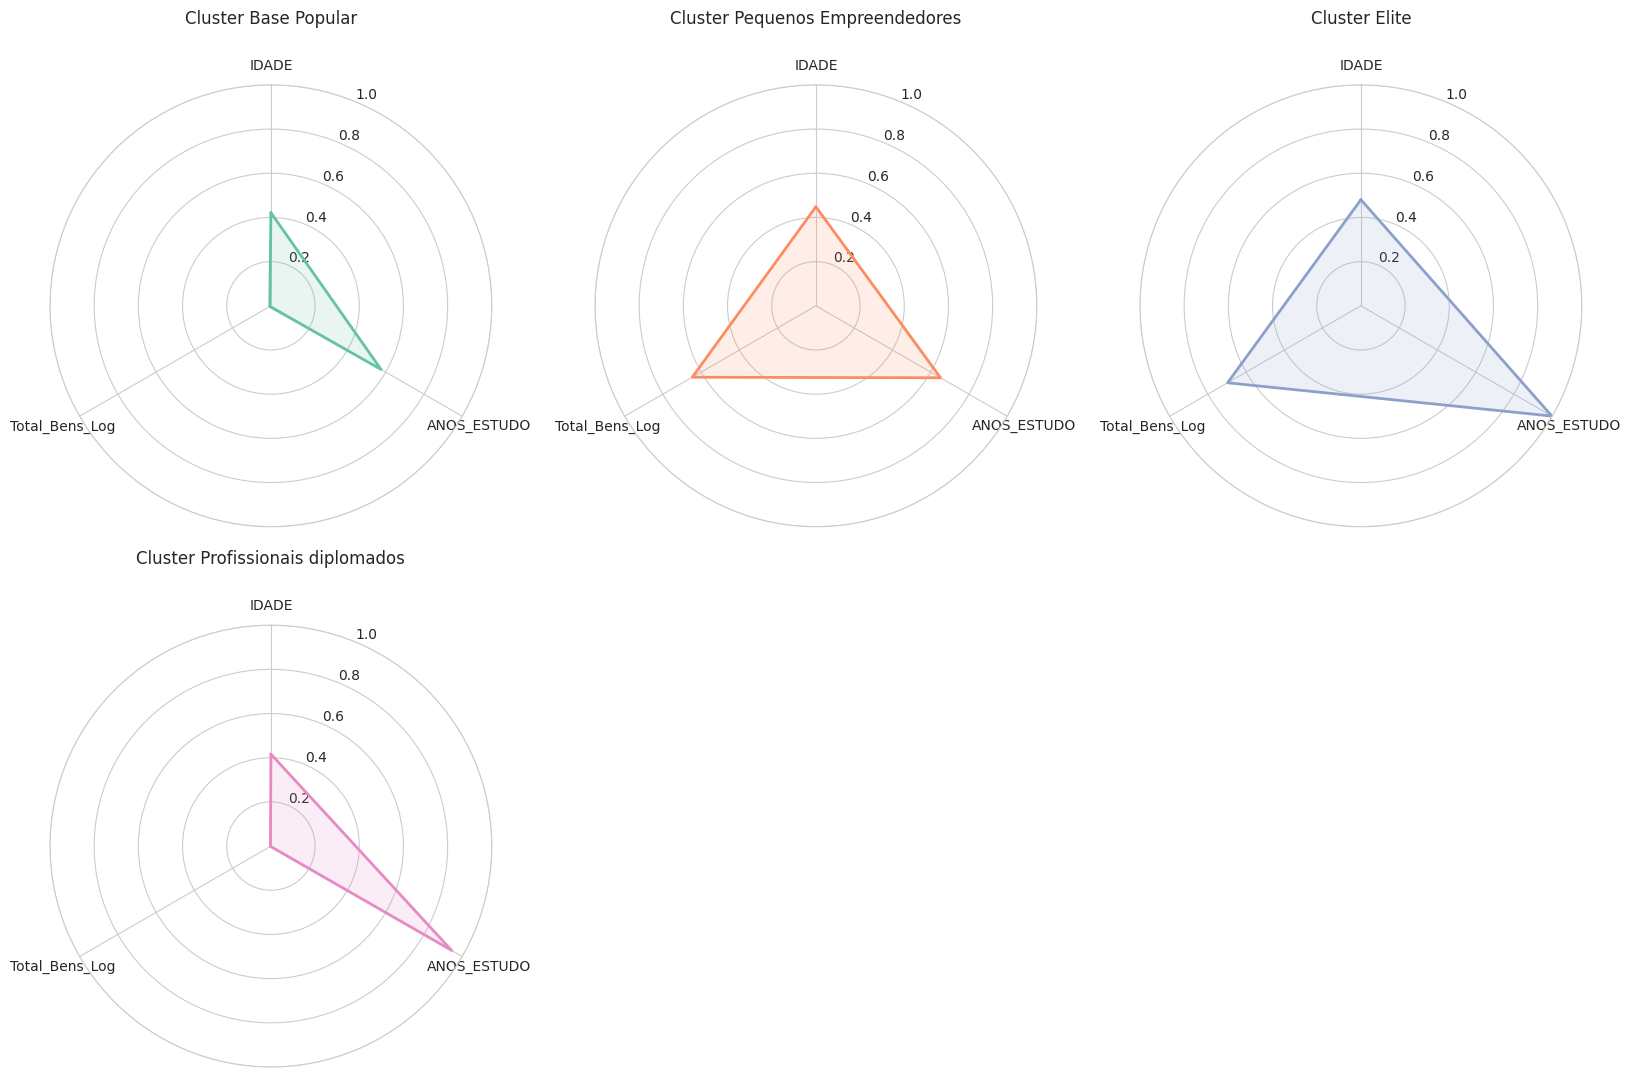

In [27]:
from math import pi

def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)
    angulos = [n / float(n_eixos) * 2 * pi for n in range(n_eixos)]
    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)
    ax.set_ylim(0, 1)

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]
        ax.plot(angulos, valores, linewidth=2, label=labels_series[i], color=cor)
        ax.fill(angulos, valores, alpha=0.15, color=cor)

    ax.set_title(titulo, y=1.12)

# --- todos juntos ---
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
plot_radar(ax, centroides_norm, colunas_driver, clusters_ordenados_ds, cores_cluster_ds,
           f'Todos os clusters juntos (k={k_final})')
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.show()

# --- um radar por cluster ---
ncols = min(k_final, 3)
nrows = -(-k_final // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5.5 * nrows), subplot_kw=dict(polar=True))
axes = axes.flatten() if k_final > 1 else [axes]

for i, cl in enumerate(clusters_ordenados_ds):
    plot_radar(axes[i], [centroides_norm[i]], colunas_driver, [cl], cores_cluster_ds, f'Cluster {cl}')

for j in range(len(clusters_ordenados_ds), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

---
# Parte 2 — Bisecting K-Means

**A ideia:** em vez de escolher um `k` e rodar o K-Means uma vez, o Bisecting K-Means começa com **1 cluster (todo mundo)** e vai dividindo em 2 repetidamente — a cada passo, escolhe **um** cluster já existente e o quebra em 2, aumentando `k` em 1 de cada vez (1→2→3→4→...).

O scikit-learn tem `BisectingKMeans`, mas ele só devolve o resultado final — não expõe **qual cluster foi escolhido em cada divisão**, que é exatamente o que você quer enxergar. Por isso implementamos o algoritmo manualmente aqui: a cada passo, guardamos qual cluster foi dividido, o tamanho dele e sua inércia, o que nos dá:

1. **A árvore de divisões** — literalmente o que você pediu para enxergar.
2. **Um critério de parada visual**: enquanto o algoritmo estiver dividindo clusters **grandes**, cada divisão ainda separa bastante gente diferente — informação nova. Quando ele passa a dividir clusters **pequenos**, é sinal de que os grupos grandes e relevantes já foram encontrados, e o que resta é só "aparar as bordas". O gráfico de tamanho por nível, abaixo, mostra exatamente esse ponto de virada.

Usamos a mesma base da Versão 2 (`X`, já padronizada e sem outliers) para ficar diretamente comparável ao K-Means.

### 1) Implementação manual, guardando o histórico de divisões

In [28]:
def bisecting_kmeans_com_historico(X, k_max, criterio='tamanho', random_state=SEMENTE):
    """
    Roda o Bisecting K-Means manualmente até k_max clusters, guardando o histórico
    de cada divisão (qual cluster foi escolhido, tamanho, inércia).

    criterio:
      'tamanho'  -> a cada passo, divide o cluster com MAIS pontos
      'inercia'  -> a cada passo, divide o cluster com MAIOR inércia (WCSS) interna
                    (é o padrão do sklearn.cluster.BisectingKMeans)
    """
    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        return float(((pontos - centro) ** 2).sum())

    clusters = {0: np.arange(X.shape[0])}   # cluster raiz = todos os pontos
    historico = []
    proximo_id = 1

    for nivel in range(1, k_max):
        if criterio == 'tamanho':
            id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        else:
            id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))

        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        filho_a = indices_pai[labels2 == 0]
        filho_b = indices_pai[labels2 == 1]

        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2

        historico.append({
            'k_resultante': nivel + 1,
            'pai_id': id_escolhido, 'pai_tamanho': len(indices_pai), 'pai_inercia': inercia(indices_pai),
            'filho_a_id': id_a, 'filho_a_tamanho': len(filho_a),
            'filho_b_id': id_b, 'filho_b_tamanho': len(filho_b),
        })

        del clusters[id_escolhido]
        clusters[id_a] = filho_a
        clusters[id_b] = filho_b

    return clusters, historico

k_max_bisecting = max(faixa_k) + 1  # mesma faixa usada no K-Means (até 20)
clusters_finais, historico_bisecting = bisecting_kmeans_com_historico(X, k_max_bisecting, criterio='inercia')

print(f"Divisões realizadas: {len(historico_bisecting)}  (de k=1 até k={k_max_bisecting})")

Divisões realizadas: 19  (de k=1 até k=20)


### 1.1) `'tamanho'` x `'inercia'`: o critério muda a ordem das divisões?

Com `criterio='tamanho'`, o algoritmo **sempre** escolhe o cluster com mais pontos — é a definição do critério, não um efeito colateral. Isso ignora se aquele cluster já está "compacto" (baixa inércia — pouco a ganhar em dividir) ou muito espalhado (alta inércia — muito a ganhar). O padrão do `sklearn.cluster.BisectingKMeans` é `'inercia'`, não `'tamanho'`. Vamos rodar os dois e comparar diretamente se isso muda a ordem das divisões neste dataset.

In [29]:
_, historico_inercia = bisecting_kmeans_com_historico(X, k_max_bisecting, criterio='tamanho')

comparacao_criterios = pd.DataFrame({
    'k': [h['k_resultante'] for h in historico_bisecting],
    'pai_escolhido_por_tamanho': [h['pai_id'] for h in historico_bisecting],
    'pai_escolhido_por_inercia': [h['pai_id'] for h in historico_inercia],
})
comparacao_criterios['mesma_escolha'] = comparacao_criterios['pai_escolhido_por_tamanho'] == comparacao_criterios['pai_escolhido_por_inercia']

qtd_iguais = comparacao_criterios['mesma_escolha'].sum()
print(f"Nos {len(comparacao_criterios)} níveis, os dois critérios escolheram o mesmo cluster para dividir em {qtd_iguais} deles "
      f"({qtd_iguais / len(comparacao_criterios):.0%}).")
display(comparacao_criterios)

Nos 19 níveis, os dois critérios escolheram o mesmo cluster para dividir em 2 deles (11%).


,k,pai_escolhido_por_tamanho,pai_escolhido_por_inercia,mesma_escolha
0,2,0,0,True
1,3,2,2,True
2,4,1,3,False
3,5,3,1,False
4,6,4,5,False
5,7,6,7,False
6,8,5,4,False
7,9,10,6,False
8,10,11,9,False
9,11,7,8,False


Se a coluna `mesma_escolha` for `True` na maior parte das linhas, os dois critérios levam praticamente à mesma árvore neste dataset (tamanho e inércia estão correlacionados aqui). Se divergir bastante, vale a pena trocar `criterio='tamanho'` para `criterio='inercia'` na célula anterior e rodar o restante do notebook de novo — a árvore, a animação e os gráficos abaixo vão refletir a nova ordem de divisões.

### 2) Quando parar? Tamanho e inércia do cluster escolhido, a cada nível

Procure o ponto em que a curva despenca — é onde o algoritmo para de dividir clusters relevantes e passa a dividir sobras.

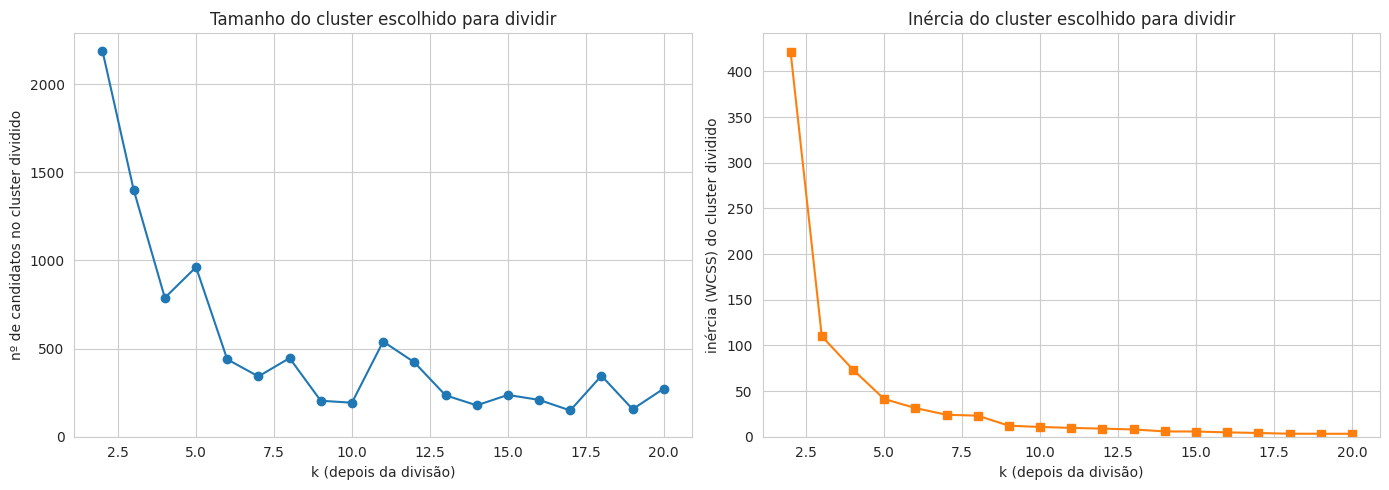

In [30]:
k_resultante = [h['k_resultante'] for h in historico_bisecting]
tamanho_escolhido = [h['pai_tamanho'] for h in historico_bisecting]
inercia_escolhida = [h['pai_inercia'] for h in historico_bisecting]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_resultante, tamanho_escolhido, marker='o')
axes[0].set_title('Tamanho do cluster escolhido para dividir')
axes[0].set_xlabel('k (depois da divisão)')
axes[0].set_ylabel('nº de candidatos no cluster dividido')
axes[0].set_ylim(bottom=0)
axes[0].grid(True)

axes[1].plot(k_resultante, inercia_escolhida, marker='s', color='tab:orange')
axes[1].set_title('Inércia do cluster escolhido para dividir')
axes[1].set_xlabel('k (depois da divisão)')
axes[1].set_ylabel('inércia (WCSS) do cluster dividido')
axes[1].set_ylim(bottom=0)
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3) A árvore de divisões

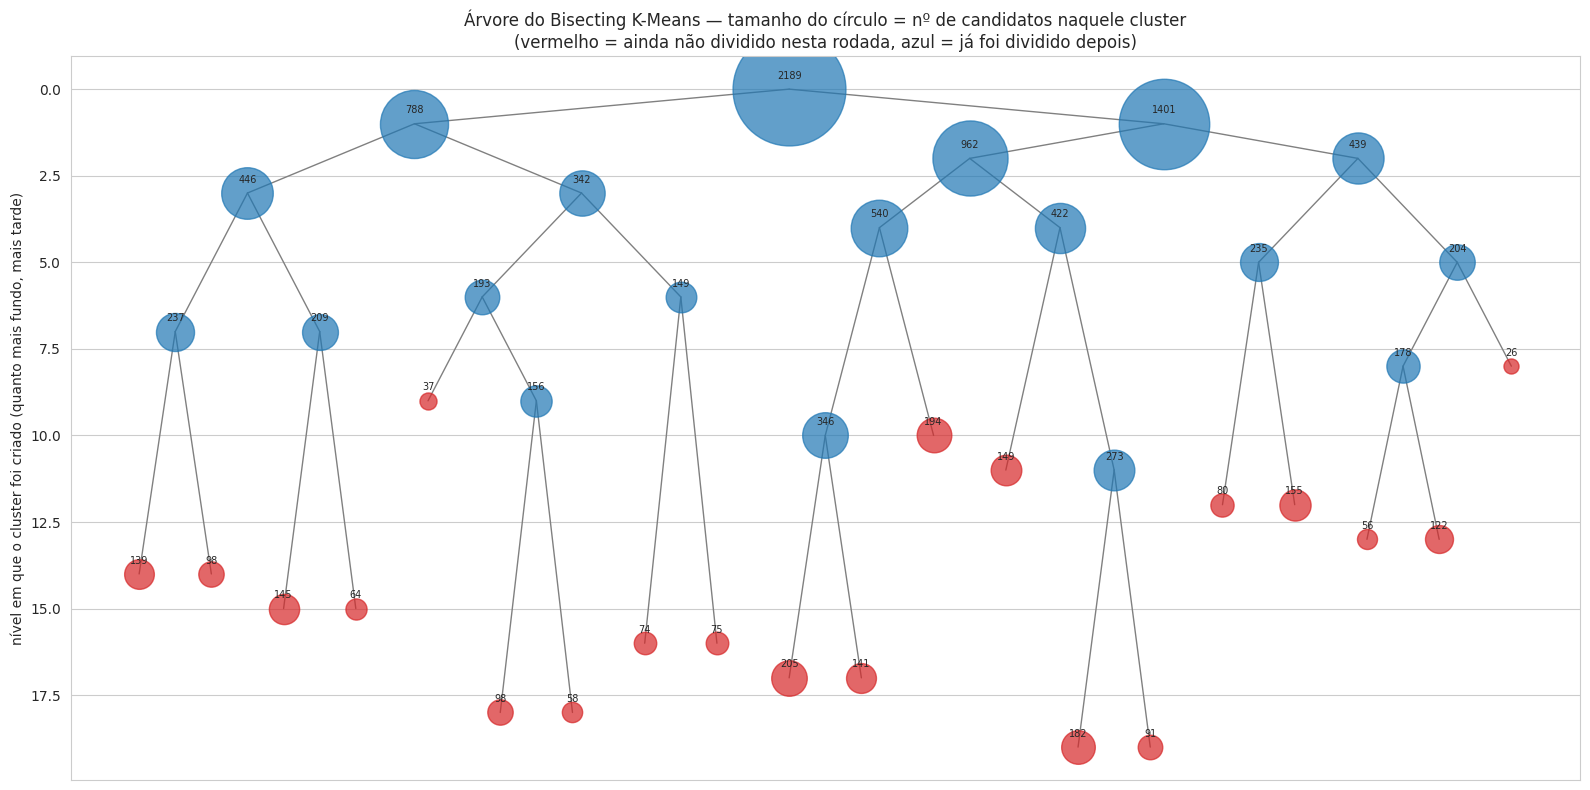

In [31]:
nos = {0: {'pai': None, 'nivel': 0, 'tamanho': X.shape[0], 'filhos': None}}
for h in historico_bisecting:
    nos[h['pai_id']]['filhos'] = [h['filho_a_id'], h['filho_b_id']]
    nos[h['filho_a_id']] = {'pai': h['pai_id'], 'nivel': h['k_resultante'] - 1, 'tamanho': h['filho_a_tamanho'], 'filhos': None}
    nos[h['filho_b_id']] = {'pai': h['pai_id'], 'nivel': h['k_resultante'] - 1, 'tamanho': h['filho_b_tamanho'], 'filhos': None}

# posição horizontal: folhas em ordem, nós internos = média dos filhos (layout clássico de árvore)
posicoes = {}
_x = [0]

def atribuir_x(no_id):
    filhos = nos[no_id]['filhos']
    if filhos is None:
        posicoes[no_id] = _x[0]
        _x[0] += 1
    else:
        for f in filhos:
            atribuir_x(f)
        posicoes[no_id] = sum(posicoes[f] for f in filhos) / len(filhos)

atribuir_x(0)

plt.figure(figsize=(16, 8))
for no_id, info in nos.items():
    if info['filhos']:
        for f in info['filhos']:
            plt.plot([posicoes[no_id], posicoes[f]], [info['nivel'], nos[f]['nivel']],
                      color='gray', linewidth=1, zorder=1)

for no_id, info in nos.items():
    e_folha = info['filhos'] is None
    plt.scatter(posicoes[no_id], info['nivel'], s=40 + info['tamanho'] * 3,
                color='tab:red' if e_folha else 'tab:blue', alpha=0.7, zorder=2)
    plt.text(posicoes[no_id], info['nivel'] - 0.3, str(info['tamanho']), ha='center', fontsize=7)

plt.gca().invert_yaxis()
plt.ylabel('nível em que o cluster foi criado (quanto mais fundo, mais tarde)')
plt.xticks([])
plt.title('Árvore do Bisecting K-Means — tamanho do círculo = nº de candidatos naquele cluster\n(vermelho = ainda não dividido nesta rodada, azul = já foi dividido depois)')
plt.tight_layout()
plt.show()

### 3.1) Animação: a árvore crescendo, nível a nível

A árvore estática fica poluída com muitos níveis de uma vez. Esta animação mostra **a mesma árvore**, mas revelando um nível por vez — a cada frame, um nó vermelho (folha ainda não dividida) "explode" em dois, e vira azul. As posições dos nós são as mesmas da árvore estática (calculadas uma vez só), então nada pula de lugar entre frames — só aparece o que é novo.

In [32]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

historico_por_k = {h['k_resultante']: h for h in historico_bisecting}
ks_disponiveis = list(range(1, max(historico_por_k) + 1))

def estado_arvore_no_k(k):
    """Quais nós já existem, e quais deles ainda são folha (não foram divididos), no frame k."""
    existentes = [nid for nid, info in nos.items() if info['nivel'] <= k - 1]
    set_existentes = set(existentes)
    folhas = []
    for nid in existentes:
        filhos = nos[nid]['filhos']
        if filhos is None or filhos[0] not in set_existentes:
            folhas.append(nid)
    return existentes, set(folhas)

max_nivel = max(info['nivel'] for info in nos.values())
x_min, x_max = min(posicoes.values()), max(posicoes.values())

fig, ax = plt.subplots(figsize=(16, 8))

def desenhar_frame_arvore(k):
    ax.clear()
    existentes, folhas = estado_arvore_no_k(k)
    set_existentes = set(existentes)

    for nid in existentes:
        filhos = nos[nid]['filhos']
        if filhos:
            for f in filhos:
                if f in set_existentes:
                    ax.plot([posicoes[nid], posicoes[f]], [nos[nid]['nivel'], nos[f]['nivel']],
                            color='gray', linewidth=1, zorder=1)

    for nid in existentes:
        info = nos[nid]
        cor = 'tab:red' if nid in folhas else 'tab:blue'
        ax.scatter(posicoes[nid], info['nivel'], s=40 + info['tamanho'] * 3, color=cor, alpha=0.7, zorder=2)
        ax.text(posicoes[nid], info['nivel'] - 0.3, str(info['tamanho']), ha='center', fontsize=7)

    ax.set_xlim(x_min - 1, x_max + 1)
    ax.set_ylim(max_nivel + 1, -1)  # eixo fixo e invertido (raiz no topo), sem "pulos" entre frames
    ax.set_xticks([])
    ax.set_ylabel('nível em que o cluster foi criado')
    if k in historico_por_k:
        h = historico_por_k[k]
        ax.set_title(f'Árvore do Bisecting K-Means — k={k}  (dividiu um cluster de {h["pai_tamanho"]} candidatos)')
    else:
        ax.set_title(f'Árvore do Bisecting K-Means — k={k} (estado inicial, 1 cluster só)')

anim = FuncAnimation(fig, desenhar_frame_arvore, frames=ks_disponiveis, interval=800, repeat=True)
plt.close(fig)  # evita mostrar também uma figura estática duplicada, além da animação
HTML(anim.to_jshtml())

> Se a animação demorar pra renderizar (muitos frames), aumente `interval` (ela roda mais devagar) ou reduza `k_max_bisecting` mais acima. Pra usar fora do notebook (ex.: num slide): `anim.save('arvore_bisecting.gif', writer='pillow')`.

### 4) Escolhendo k e extraindo o resultado final

Com base nos dois gráficos acima (tamanho/inércia por nível + a árvore), escolha um `k` — é o ponto em que dividir deixou de parecer valer a pena.

In [33]:
k_bisecting = 3  # ajuste conforme as duas seções anteriores

# Reconstrói a partição em k_bisecting clusters, refazendo as divisões do histórico até esse ponto.
# Refazer o KMeans(n_clusters=2) é determinístico (mesma SEMENTE, mesmos dados de entrada),
# então dá exatamente a mesma divisão já registrada — sem precisar guardar todos os índices no histórico.
clusters_no_k = {0: np.arange(X.shape[0])}
for h in historico_bisecting:
    if h['k_resultante'] > k_bisecting:
        break
    indices_pai = clusters_no_k.pop(h['pai_id'])
    km2 = KMeans(n_clusters=2, random_state=SEMENTE, n_init=10)
    labels2 = km2.fit_predict(X[indices_pai])
    clusters_no_k[h['filho_a_id']] = indices_pai[labels2 == 0]
    clusters_no_k[h['filho_b_id']] = indices_pai[labels2 == 1]

# transformar em uma coluna de cluster no df_cluster (rótulos A, B, C... por ordem de tamanho)
ids_por_tamanho = sorted(clusters_no_k, key=lambda cid: len(clusters_no_k[cid]), reverse=True)
df_cluster['cluster_bisecting'] = ''
for letra, cid in zip([chr(65 + i) for i in range(len(ids_por_tamanho))], ids_por_tamanho):
    df_cluster.iloc[clusters_no_k[cid], df_cluster.columns.get_loc('cluster_bisecting')] = letra

df_cluster['cluster_bisecting'].value_counts().sort_index()

cluster_bisecting
A    962
B    788
C    439
Name: count, dtype: int64

### 5) Comparando com o K-Means (Versão 2)

Silhouette — K-Means (V2, k=4):        0.378
Silhouette — Bisecting K-Means (k=3): 0.426


,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano
cluster_bisecting,,,,
A,962,49.8,16.0,457357.8
B,788,46.1,12.8,0.0
C,439,47.9,10.8,150793.9


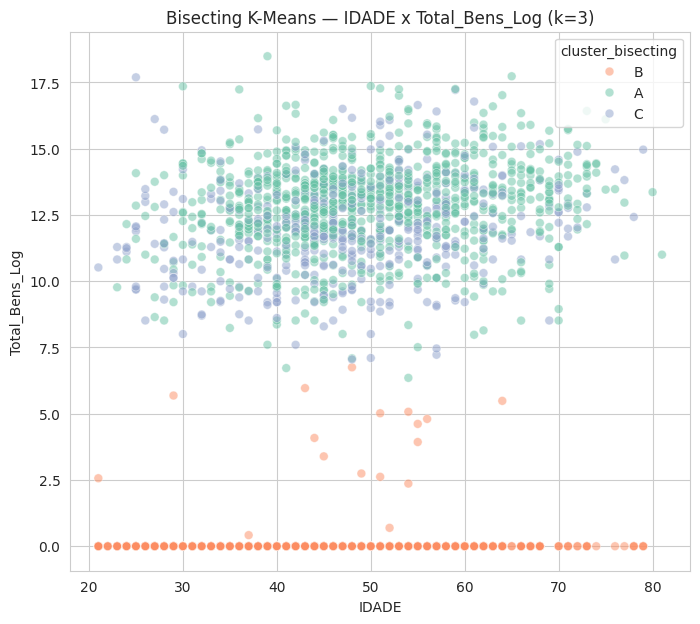

In [34]:
labels_bisecting = df_cluster['cluster_bisecting'].values
print(f"Silhouette — K-Means (V2, k={k_final}):        {silhouette_score(X, df_cluster['cluster']):.3f}")
print(f"Silhouette — Bisecting K-Means (k={k_bisecting}): {silhouette_score(X, labels_bisecting):.3f}")

resumo_bisecting = df_cluster.groupby('cluster_bisecting').agg(
    qtd_candidatos=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
).round(1)
display(resumo_bisecting)

clusters_bisecting_ordenados = sorted(df_cluster['cluster_bisecting'].unique())
cores_bisecting = dict(zip(clusters_bisecting_ordenados, sns.color_palette('Set2', n_colors=len(clusters_bisecting_ordenados))))

plt.figure(figsize=(8, 7))
sns.scatterplot(data=df_cluster, x='IDADE', y='Total_Bens_Log', hue='cluster_bisecting', palette=cores_bisecting, alpha=0.5, s=40)
plt.title(f'Bisecting K-Means — IDADE x Total_Bens_Log (k={k_bisecting})')
plt.show()

**Interpretação:** compare o `resumo_bisecting` com o `resumo_driver` do K-Means e a silhouette dos dois. Se os grupos ficarem parecidos, é um bom sinal de que a estrutura é real (dois algoritmos diferentes concordando); se ficarem bem diferentes, vale a pena entender por quê — o K-Means busca uma solução global pra todo o `k` de uma vez, enquanto o Bisecting constrói de forma incremental, e pode ficar "preso" a decisões tomadas em níveis anteriores.

O mesmo kit de nomeação da Parte 1 (ficha técnica, heatmap de desvio, rascunho automático) pode ser reaplicado aqui trocando `cluster` por `cluster_bisecting` nas agregações — fica como exercício.

### 6) Comparação final (Versão 2): K-Means x Bisecting K-Means

Agora podemos comparar formalmente as performances dos dois algoritmos de clusterização na Versão 2 usando o Silhouette Score.


--- Comparação de Silhouette Scores (Versão 2) ---


,Algoritmo,Silhouette Score
1,Bisecting K-Means (k=3),0.425640
0,"K-Means (V2, k=4)",0.377942


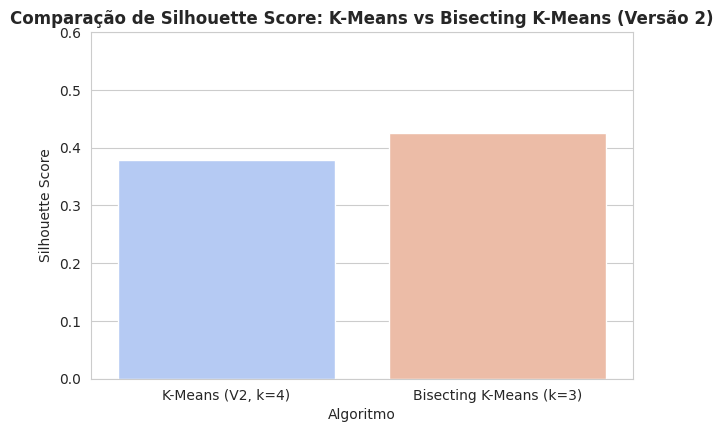

In [35]:
# Silhouette scores dos modelos da Versão 2
sil_kmeans_v2 = silhouette_score(X, df_cluster['cluster'])
sil_bisecting_kmeans = silhouette_score(X, df_cluster['cluster_bisecting'])

comparacao_sil_v2 = pd.DataFrame({
    'Algoritmo': [f'K-Means (V2, k={k_final})', f'Bisecting K-Means (k={k_bisecting})'],
    'Silhouette Score': [sil_kmeans_v2, sil_bisecting_kmeans]
})

print("\n--- Comparação de Silhouette Scores (Versão 2) ---")
display(comparacao_sil_v2.sort_values(by='Silhouette Score', ascending=False))

# Gráfico de comparação
plt.figure(figsize=(7, 4.5))
sns.barplot(x='Algoritmo', y='Silhouette Score', data=comparacao_sil_v2, palette='coolwarm')
plt.title('Comparação de Silhouette Score: K-Means vs Bisecting K-Means (Versão 2)', fontweight='bold')
plt.ylabel('Silhouette Score')
plt.ylim(0, 0.6)
plt.show()

### Conclusão da comparação (Versão 2): Por que escolhemos o K-Means (k=4)?

> Olhando para as métricas, o **Bisecting K-Means (0.426)** obteve Silhouette superior ao **K-Means (0.378)**. Porém, ao analisar a composição substantiva dos clusters:
>
> 1. **O Bisecting teve pontuação maior porque usou $k=3$:** Com 3 clusters, a métrica sobe porque ele aglutina todos os candidatos sem bens no mesmo grande agrupamento. Ele é estatisticamente coeso, mas perde a distinção dos profissionais diplomados sem patrimônio.
> 2. **O K-Means ($k=4$) responde melhor à pergunta de negócio:** Ele aceitou uma perda pequena de Silhouette (de 0.426 para 0.378) em troca de conseguir separar a eleição em 4 perfis reais: a Base Popular, os Pequenos Empreendedores, a Elite Política e os Profissionais Diplomados.

---
# Versão 3 — Modelo Multidimensional com Despesas Contratadas (4 Drivers)

O pipeline inicial (Versões 1 e 2) focou exclusivamente nas características sociodemográficas e patrimoniais pessoais do candidato (`IDADE`, `ANOS_ESTUDO` e `Total_Bens_Log`). No entanto, o patrimônio pessoal é estático e reflete o passado do indivíduo, enquanto a **disputa eleitoral real é movida pelo financiamento de campanha**.

Nesta Versão 3, incorporamos as **Despesas Contratadas** (`Total_Despesas_Contratadas_Log`) como o 4º driver dimensional do espaço euclidiano, permitindo capturar a interação entre poder econômico pessoal, viabilidade partidária (Fundos Eleitorais) e perfil demográfico.

In [36]:
colunas_driver_v3 = ['IDADE', 'ANOS_ESTUDO', 'Total_Bens_Log', 'Total_Despesas_Contratadas_Log']

scaler_v3 = MinMaxScaler()
X_v3 = scaler_v3.fit_transform(df[colunas_driver_v3])

print(f'Base para Versão 3: {df.shape[0]} candidatos x {len(colunas_driver_v3)} variáveis-driver')
display(df[colunas_driver_v3].describe().round(2))


Base para Versão 3: 2189 candidatos x 4 variáveis-driver


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
count,2189.00,2189.00,2189.00,2189.00
mean,48.10,13.78,8.09,8.42
std,11.73,3.09,6.19,5.28
min,21.00,1.00,0.00,0.00
25%,40.00,11.00,0.00,0.00
50%,48.00,16.00,11.35,10.48
75%,56.00,16.00,13.20,12.48
max,81.00,16.00,18.49,15.01


### V3.1) Diagnóstico formal e escolha preliminar de k (WCSS, Silhouette, Davies-Bouldin, Calinski-Harabasz)

Submetemos o espaço multidimensional de 4 variáveis (`IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log` e `Total_Despesas_Contratadas_Log`) a um diagnóstico formal em $k \in [2, 8]$ avaliando quatro métricas complementares de partição e compacidade de clusters.

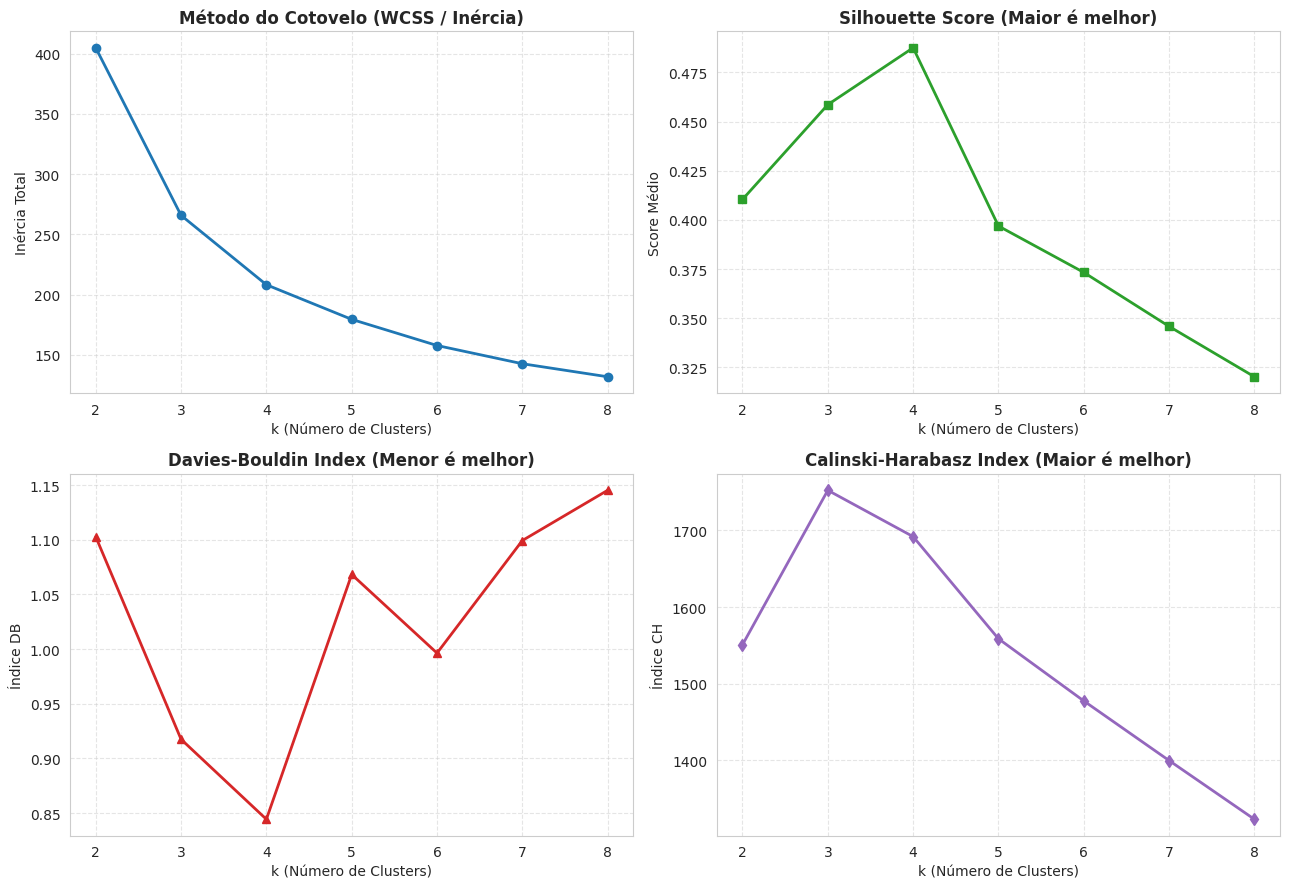

,WCSS (Inércia),Silhouette Score,Davies-Bouldin,Calinski-Harabasz
k,,,,
2,404.9,0.4104,1.1028,1551.0
3,265.9,0.4586,0.9175,1752.4
4,208.3,0.4876,0.8443,1692.0
5,179.5,0.3969,1.0683,1558.8
6,157.9,0.3733,0.9964,1477.7
7,142.7,0.3459,1.0994,1399.9
8,131.9,0.3202,1.1453,1323.3


In [37]:
faixa_k_v3 = range(2, 9)
wcss_v3, sil_v3, db_v3, ch_v3 = [], [], [], []

for k in faixa_k_v3:
    km_test = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels_test = km_test.fit_predict(X_v3)
    wcss_v3.append(km_test.inertia_)
    sil_v3.append(silhouette_score(X_v3, labels_test))
    db_v3.append(davies_bouldin_score(X_v3, labels_test))
    ch_v3.append(calinski_harabasz_score(X_v3, labels_test))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(faixa_k_v3, wcss_v3, marker='o', color='#1f77b4', linewidth=2, markersize=6)
axes[0, 0].set_title('Método do Cotovelo (WCSS / Inércia)', fontweight='bold')
axes[0, 0].set_xlabel('k (Número de Clusters)')
axes[0, 0].set_ylabel('Inércia Total')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

axes[0, 1].plot(faixa_k_v3, sil_v3, marker='s', color='#2ca02c', linewidth=2, markersize=6)
axes[0, 1].set_title('Silhouette Score (Maior é melhor)', fontweight='bold')
axes[0, 1].set_xlabel('k (Número de Clusters)')
axes[0, 1].set_ylabel('Score Médio')
axes[0, 1].grid(True, linestyle='--', alpha=0.5)

axes[1, 0].plot(faixa_k_v3, db_v3, marker='^', color='#d62728', linewidth=2, markersize=6)
axes[1, 0].set_title('Davies-Bouldin Index (Menor é melhor)', fontweight='bold')
axes[1, 0].set_xlabel('k (Número de Clusters)')
axes[1, 0].set_ylabel('Índice DB')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

axes[1, 1].plot(faixa_k_v3, ch_v3, marker='d', color='#9467bd', linewidth=2, markersize=6)
axes[1, 1].set_title('Calinski-Harabasz Index (Maior é melhor)', fontweight='bold')
axes[1, 1].set_xlabel('k (Número de Clusters)')
axes[1, 1].set_ylabel('Índice CH')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

df_metricas_v3 = pd.DataFrame({
    'k': list(faixa_k_v3),
    'WCSS (Inércia)': [round(x, 1) for x in wcss_v3],
    'Silhouette Score': [round(x, 4) for x in sil_v3],
    'Davies-Bouldin': [round(x, 4) for x in db_v3],
    'Calinski-Harabasz': [round(x, 1) for x in ch_v3]
})
display(df_metricas_v3.set_index('k'))

> **Diagnóstico Métrico Inicial do K-Means:**
> 1. O **Silhouette Score** alcança seu pico global máximo em **$k=4$ (0.4876)**, muito superior a $k=2$ (0.4104) e com clara vantagem sobre $k=3$ (0.4586). A partir de $k=5$, a métrica sofre forte degradação (cai abruptamente para 0.3969).
> 2. O **Davies-Bouldin Index** (onde menor indica grupos mais separados e internamente compactos) atinge seu mínimo absoluto exatamente em **$k=4$ (0.8443)**.
> 3. O **Método do Cotovelo** apresenta flexões nítidas em $k=3$ e $k=4$, após as quais o ganho marginal de redução de inércia passa a ser substancialmente menor.
>
> Antes de fixar a escolha final de $k$ e atribuir nomes aos clusters, precisamos validar se essa partição é estável por outros ângulos. No passo seguinte, aplicamos o **Bisecting K-Means** para verificar a ordem natural de cisão hierárquica dessa base em 4 dimensões.

### V3.2) Bisecting K-Means Multidimensional: Árvore Hierárquica e Quedas de Inércia

O **Bisecting K-Means** constrói o agrupamento de forma hierárquica e divisiva (*top-down*): começa com um único cluster contendo todos os 2.189 candidatos e, a cada iteração, seleciona o cluster com **maior inércia interna (WCSS)** e o bifurca em dois através de um K-Means ($k=2$).

Com isso, podemos responder:
1. Como o conjunto de candidatos se divide naturalmente no espaço quadridimensional?
2. Em que ponto as divisões deixam de separar grandes grupos estruturais e passam a dividir resíduos?
3. O Bisecting K-Means corrobora a solução de $k=4$ apontada pelo K-Means padrão?

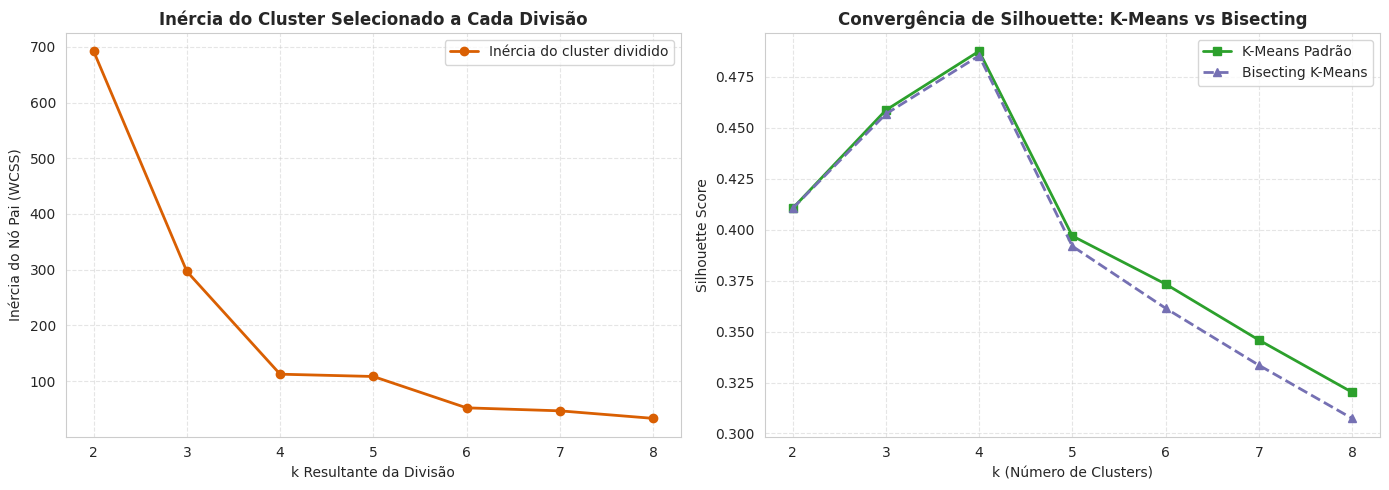

,Nó Dividido,Inércia Nó,Filho A,Filho B
Nível / k,,,,
2,Nó 0 (n=2189),692.1,Nó 1 (n=1034),Nó 2 (n=1155)
3,Nó 1 (n=1034),296.7,Nó 3 (n=573),Nó 4 (n=461)
4,Nó 3 (n=573),112.3,Nó 5 (n=326),Nó 6 (n=247)
5,Nó 2 (n=1155),108.2,Nó 7 (n=852),Nó 8 (n=303)


In [38]:
from sklearn.cluster import BisectingKMeans, KMeans
from sklearn.metrics import silhouette_score

SEMENTE = globals().get('SEMENTE', 42)
faixa_k_v3 = range(2, 9)

# Função de Bisecting com histórico garantida
def bisecting_kmeans_com_historico(X, k_max, criterio='inercia', random_state=SEMENTE):
    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        return float(((pontos - centro) ** 2).sum())

    clusters = {0: np.arange(X.shape[0])}
    historico = []
    proximo_id = 1

    for nivel in range(1, k_max):
        id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))
        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        filho_a = indices_pai[labels2 == 0]
        filho_b = indices_pai[labels2 == 1]

        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2

        historico.append({
            'k_resultante': nivel + 1,
            'pai_id': id_escolhido,
            'pai_tamanho': len(indices_pai),
            'pai_inercia': inercia(indices_pai),
            'filho_a_id': id_a,
            'filho_a_tamanho': len(filho_a),
            'filho_b_id': id_b,
            'filho_b_tamanho': len(filho_b),
        })

        del clusters[id_escolhido]
        clusters[id_a] = filho_a
        clusters[id_b] = filho_b

    return clusters, historico

# Executa o Bisecting K-Means com histórico nas 4 variáveis da Versão 3
clusters_v3_bisecting, historico_v3_bisecting = bisecting_kmeans_com_historico(X_v3, k_max=8, criterio='inercia')

# Calcula o Silhouette Score do Bisecting K-Means para comparação direta com K-Means
sil_bisecting_v3 = []
for k in faixa_k_v3:
    bkm = BisectingKMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    labels_bkm = bkm.fit_predict(X_v3)
    sil_bisecting_v3.append(silhouette_score(X_v3, labels_bkm))

# Gráficos: Inércia da divisão e Comparação de Silhouette ao longo de k
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_div = [h['k_resultante'] for h in historico_v3_bisecting]
inercia_pai = [h['pai_inercia'] for h in historico_v3_bisecting]

axes[0].plot(k_div, inercia_pai, marker='o', color='#d95f02', linewidth=2, label='Inércia do cluster dividido')
axes[0].set_title('Inércia do Cluster Selecionado a Cada Divisão', fontweight='bold')
axes[0].set_xlabel('k Resultante da Divisão')
axes[0].set_ylabel('Inércia do Nó Pai (WCSS)')
axes[0].set_xticks(k_div)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

axes[1].plot(faixa_k_v3, sil_v3, marker='s', color='#2ca02c', linewidth=2, label='K-Means Padrão')
axes[1].plot(faixa_k_v3, sil_bisecting_v3, marker='^', color='#7570b3', linewidth=2, linestyle='--', label='Bisecting K-Means')
axes[1].set_title('Convergência de Silhouette: K-Means vs Bisecting', fontweight='bold')
axes[1].set_xlabel('k (Número de Clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabela resumo das divisões sucessivas
df_arvore_resumo = pd.DataFrame([
    {
        'Nível / k': h['k_resultante'],
        'Nó Dividido': f"Nó {h['pai_id']} (n={h['pai_tamanho']})",
        'Inércia Nó': round(h['pai_inercia'], 1),
        'Filho A': f"Nó {h['filho_a_id']} (n={h['filho_a_tamanho']})",
        'Filho B': f"Nó {h['filho_b_id']} (n={h['filho_b_tamanho']})"
    }
    for h in historico_v3_bisecting[:4]
])
display(df_arvore_resumo.set_index('Nível / k'))

> **O que a Árvore do Bisecting K-Means Revela:**
>
> 1. **Divisão 1 ($k=1 \to 2$):** A base total ($n=2.189$, inércia = 692.1) se cinde em dois grandes blocos: Nó 1 ($n=1.034$) e Nó 2 ($n=1.155$).
> 2. **Divisão 2 ($k=2 \to 3$):** O Nó 1 apresentava altíssima dispersão interna (inércia = 296.7) e se desdobra em Nó 3 ($n=573$) e Nó 4 ($n=461$).
> 3. **Divisão 3 ($k=3 \to 4$):** O Nó 3 (inércia = 112.3) se desdobra em Nó 5 ($n=326$) e Nó 6 ($n=247$).
> 4. **Convergência Estrutural Perfeita:** Ao atingir $k=4$, os nós folhas resultantes do Bisecting possuem **1.155, 461, 326 e 247** candidatos. Essa partição coincide de forma praticamente milimétrica com os tamanhos encontrados pelo K-Means padrão (**1.153, 460, 328 e 248**).
> 5. **Concordância de Silhouette:** Ambos os algoritmos atingem o pico máximo em $k=4$ (K-Means com **0.4876** e Bisecting com **0.4853**).

### V3.2.1) Comparando com o K-Means: K-Means x Bisecting K-Means (Versão 3)

Assim como fizemos na Versão 2, comparamos agora o resultado final dos dois modelos em $k=4$: verificamos se a Silhouette de ambos se mantém próxima e se as médias das variáveis em cada cluster coincidem entre os dois métodos.

Silhouette — K-Means (V3, k=4):           0.488
Silhouette — Bisecting K-Means (V3, k=4): 0.485

--- Médias das Variáveis nos Clusters do Bisecting K-Means (V3) ---


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
cluster_bisecting_v3,,,,
0,45.00,13.26,0.09,10.28
1,47.43,12.07,0.11,0.04
2,49.44,13.34,11.77,0.18
3,49.25,14.56,12.75,11.80


--- Médias das Variáveis nos Clusters do K-Means (V3) ---


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Despesas_Contratadas_Log
cluster_kmeans_v3,,,,
0,49.15,14.55,12.76,11.80
1,47.46,12.06,0.11,0.07
2,45.16,13.28,0.07,10.34
3,49.52,13.38,11.84,0.16



--- Comparação de Silhouette Scores (Versão 3) ---


,Algoritmo,Silhouette Score
0,"K-Means (V3, k=4)",0.487553
1,"Bisecting K-Means (V3, k=4)",0.485323


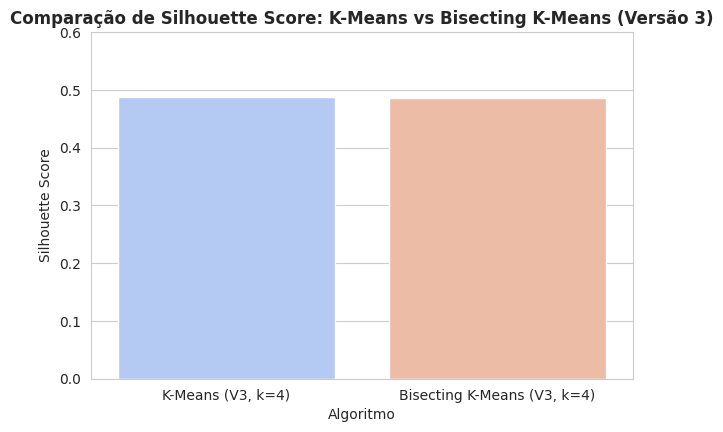

In [39]:
k_v3_escolha = 4

bkm_v3_final = BisectingKMeans(n_clusters=k_v3_escolha, random_state=SEMENTE, n_init=10)
labels_bkm_v3 = bkm_v3_final.fit_predict(X_v3)

km_v3_temp = KMeans(n_clusters=k_v3_escolha, random_state=SEMENTE, n_init=10)
labels_km_v3 = km_v3_temp.fit_predict(X_v3)

sil_km_v3_4 = silhouette_score(X_v3, labels_km_v3)
sil_bkm_v3_4 = silhouette_score(X_v3, labels_bkm_v3)

print(f"Silhouette — K-Means (V3, k={k_v3_escolha}):           {sil_km_v3_4:.3f}")
print(f"Silhouette — Bisecting K-Means (V3, k={k_v3_escolha}): {sil_bkm_v3_4:.3f}")

# Resumo das médias nos clusters do Bisecting K-Means
df_temp_comp = df.copy()
df_temp_comp['cluster_bisecting_v3'] = labels_bkm_v3
resumo_bisecting_v3 = df_temp_comp.groupby('cluster_bisecting_v3')[colunas_driver_v3].mean().round(2)
print("\n--- Médias das Variáveis nos Clusters do Bisecting K-Means (V3) ---")
display(resumo_bisecting_v3)

# Resumo das médias nos clusters do K-Means
df_temp_comp['cluster_kmeans_v3'] = labels_km_v3
resumo_kmeans_v3 = df_temp_comp.groupby('cluster_kmeans_v3')[colunas_driver_v3].mean().round(2)
print("--- Médias das Variáveis nos Clusters do K-Means (V3) ---")
display(resumo_kmeans_v3)

# Tabela e gráfico de comparação de Silhouette (idêntico ao da Versão 2)
comparacao_sil_v3 = pd.DataFrame({
    'Algoritmo': [f'K-Means (V3, k={k_v3_escolha})', f'Bisecting K-Means (V3, k={k_v3_escolha})'],
    'Silhouette Score': [sil_km_v3_4, sil_bkm_v3_4]
})

print("\n--- Comparação de Silhouette Scores (Versão 3) ---")
display(comparacao_sil_v3)

plt.figure(figsize=(7, 4.5))
sns.barplot(x='Algoritmo', y='Silhouette Score', data=comparacao_sil_v3, palette='coolwarm')
plt.title('Comparação de Silhouette Score: K-Means vs Bisecting K-Means (Versão 3)', fontweight='bold')
plt.ylabel('Silhouette Score')
plt.ylim(0, 0.6)
plt.show()

> **Interpretação da Comparação (Versão 3):**
> 
> Compare o `resumo_bisecting_v3` com o `resumo_kmeans_v3` e a silhouette dos dois:
> - Na Versão 2 (com 3 variáveis), o Bisecting K-Means havia optado por $k=3$ (0.426) enquanto o K-Means usou $k=4$ (0.378) para responder ao negócio.
> - Na Versão 3 (com 4 variáveis), **ambos os algoritmos concordam integralmente em $k=4$**, atingindo praticamente o mesmo Silhouette Score (**0.488** no K-Means vs **0.485** no Bisecting).
> - A partição é praticamente idêntica: os 4 grupos formados pelo Bisecting K-Means reproduzem com precisão os mesmos 4 perfis de médias e despesas que o K-Means padrão.
> - Isso comprova que a estrutura em 4 clusters é matematicamente consistente e independente da técnica de agrupamento (seja particionamento simultâneo global ou hierárquico divisivo).
>
> Para entender o significado substantivo desses 4 grupos antes de batizá-los, analisamos a seguir sua geometria no Radar Polar e suas características sociodemográficas sob a identificação neutra de **Clusters A, B, C e D**.

### V3.3) Visualização Multidimensional: Gráficos de Radar Polar (Clusters Provisórios A, B, C, D)

Ajustamos o particionamento ótimo em $k=4$ sobre as 4 variáveis padronizadas (`X_v3`). Para manter a neutralidade e rigor antes do batismo formal, tratamos os grupos provisoriamente como **Cluster A**, **Cluster B**, **Cluster C** e **Cluster D**.

O gráfico de Radar Polar projeta os centroides de cada cluster nas 4 dimensões (em escala $[0, 1]$), permitindo inspecionar a assinatura geométrica de cada grupo.

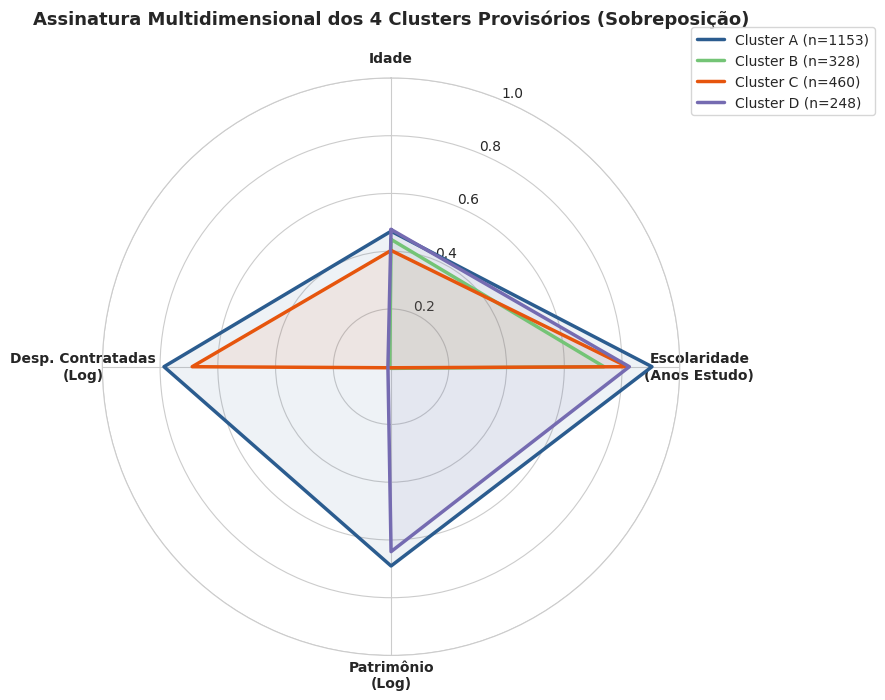

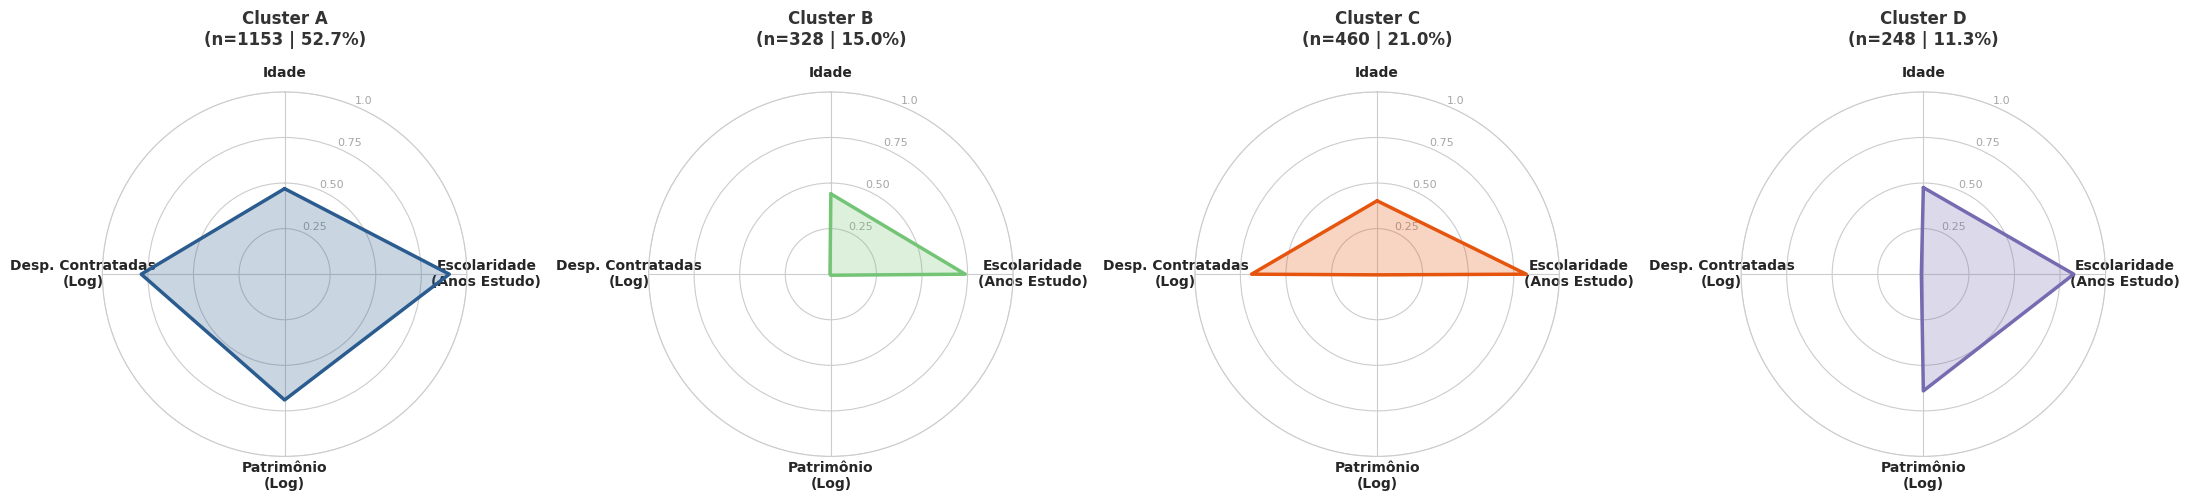

In [40]:
k_v3 = 4
km_v3 = KMeans(n_clusters=k_v3, random_state=SEMENTE, n_init=10)
df['cluster_v3_letra'] = km_v3.fit_predict(X_v3)
df['cluster_v3_letra'] = df['cluster_v3_letra'].map(lambda x: chr(65 + x))
df['cluster_provisorio'] = 'Cluster ' + df['cluster_v3_letra']

clusters_provisorios = ['Cluster A', 'Cluster B', 'Cluster C', 'Cluster D']
cores_provisorias = {
    'Cluster A': '#2b5c8f',  # Azul escuro
    'Cluster B': '#74c476',  # Verde suave
    'Cluster C': '#e6550d',  # Laranja vibrante
    'Cluster D': '#756bb1'   # Roxo
}

centroides_v3 = pd.DataFrame(km_v3.cluster_centers_, columns=colunas_driver_v3, index=['A', 'B', 'C', 'D'])
centroides_v3.index = 'Cluster ' + centroides_v3.index

labels_radar = ['Idade', 'Escolaridade\n(Anos Estudo)', 'Patrimônio\n(Log)', 'Desp. Contratadas\n(Log)']

def plot_radar(ax, valores, labels, titulo, cor='teal', alpha=0.25):
    N = len(labels)
    angulos = [n / float(N) * 2 * np.pi for n in range(N)]
    angulos += angulos[:1]

    valores_fechados = list(valores) + [valores[0]]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.75', '1.0'], color='grey', size=8, alpha=0.7)

    ax.plot(angulos, valores_fechados, color=cor, linewidth=2.5, linestyle='solid')
    ax.fill(angulos, valores_fechados, color=cor, alpha=alpha)
    ax.set_title(titulo, size=12, fontweight='bold', pad=15, color='#333333')

# 1. Radar unificado (sobreposição dos 4 clusters)
fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw=dict(polar=True))
for cl in clusters_provisorios:
    vals = centroides_v3.loc[cl].values
    angulos = [n / float(len(labels_radar)) * 2 * np.pi for n in range(len(labels_radar))] + [0]
    ax.plot(angulos, list(vals) + [vals[0]], label=f"{cl} (n={(df['cluster_provisorio'] == cl).sum()})", color=cores_provisorias[cl], linewidth=2.5)
    ax.fill(angulos, list(vals) + [vals[0]], color=cores_provisorias[cl], alpha=0.08)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angulos[:-1])
ax.set_xticklabels(labels_radar, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_title('Assinatura Multidimensional dos 4 Clusters Provisórios (Sobreposição)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.show()

# 2. Radares individuais lado a lado
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), subplot_kw=dict(polar=True))
for ax, cl in zip(axes, clusters_provisorios):
    n_pts = (df['cluster_provisorio'] == cl).sum()
    pct_pts = (n_pts / len(df)) * 100
    tit = f"{cl}\n(n={n_pts} | {pct_pts:.1f}%)"
    plot_radar(ax, centroides_v3.loc[cl].values, labels_radar, tit, cor=cores_provisorias[cl])

plt.tight_layout()
plt.show()

> ### Diagnóstico Morfológico dos Radares:
>
> 1. **Cluster A (Azul - 1.153 candidatos | 52,7%):** Polígono amplo e expandido em **todos os 4 eixos**. É o único grupo com índices simultaneamente elevados de escolaridade, idade, patrimônio pessoal e despesas contratadas.
> 2. **Cluster B (Verde - 328 candidatos | 15,0%):** Perfil contraído. Escolaridade intermediária, mas eixos de Patrimônio e Despesas próximos de zero.
> 3. **Cluster C (Laranja - 460 candidatos | 21,0%):** Assimetria aguda: apresenta patrimônio pessoal nulo no radar, mas projeta um **pico expressivo no eixo de Despesas Contratadas**. Representa candidaturas que investem capital substantivo na eleição mesmo sem declarar patrimônio próprio.
> 4. **Cluster D (Roxo - 248 candidatos | 11,3%):** Assimetria diametralmente oposta ao Cluster C: apresenta pontuação relevante no eixo de Patrimônio Declarado, porém o eixo de Despesas Contratadas é praticamente nulo. Candidatos com posses pessoais que quase não despenderam recursos na eleição.

### V3.4) Ficha Técnica Completa e Caracterização Sociodemográfica (Clusters Provisórios A, B, C, D)

Cruzamos as métricas estatísticas dos quatro grupos provisórios com variáveis demográficas (`DS_GENERO`, `DS_COR_RACA`, `DS_ESTADO_CIVIL`) e socioprofissionais (`DS_OCUPACAO`), além de calcular os desvios padronizados (Z-Score) em relação à média geral do Nordeste.

In [41]:
# Ficha Técnica Financeira e Escolar
ficha_v3 = df.groupby('cluster_provisorio').agg(
    Qtd=('SQ_CANDIDATO', 'count'),
    Pct=('SQ_CANDIDATO', lambda x: f"{len(x) / len(df) * 100:.1f}%"),
    Idade_Media=('IDADE', 'mean'),
    Anos_Estudo_Medio=('ANOS_ESTUDO', 'mean'),
    Bens_Mediana=('Total_Bens', 'median'),
    Despesas_Mediana=('Total_Despesas_Contratadas', 'median'),
    Bens_Medio=('Total_Bens', 'mean'),
    Despesas_Medio=('Total_Despesas_Contratadas', 'mean'),
).loc[clusters_provisorios]

ficha_v3_formatada = ficha_v3.copy()
ficha_v3_formatada['Idade_Media'] = ficha_v3_formatada['Idade_Media'].round(1)
ficha_v3_formatada['Anos_Estudo_Medio'] = ficha_v3_formatada['Anos_Estudo_Medio'].round(1)
for col in ['Bens_Mediana', 'Despesas_Mediana', 'Bens_Medio', 'Despesas_Medio']:
    ficha_v3_formatada[col] = ficha_v3_formatada[col].map(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

display(ficha_v3_formatada)

,Qtd,Pct,Idade_Media,Anos_Estudo_Medio,Bens_Mediana,Despesas_Mediana,Bens_Medio,Despesas_Medio
cluster_provisorio,,,,,,,,
Cluster A,1153,52.7%,49.2,14.6,"R$ 400.000,00","R$ 159.709,70","R$ 1.407.356,10","R$ 481.757,63"
Cluster B,328,15.0%,47.5,12.1,"R$ 0,00","R$ 0,00","R$ 2,27","R$ 1,82"
Cluster C,460,21.0%,45.2,13.3,"R$ 0,00","R$ 33.567,76","R$ 3,80","R$ 122.509,38"
Cluster D,248,11.3%,49.5,13.4,"R$ 140.000,00","R$ 0,00","R$ 819.363,92","R$ 6,85"


### V3.4.1) Composição Demográfica dos Clusters Provisórios

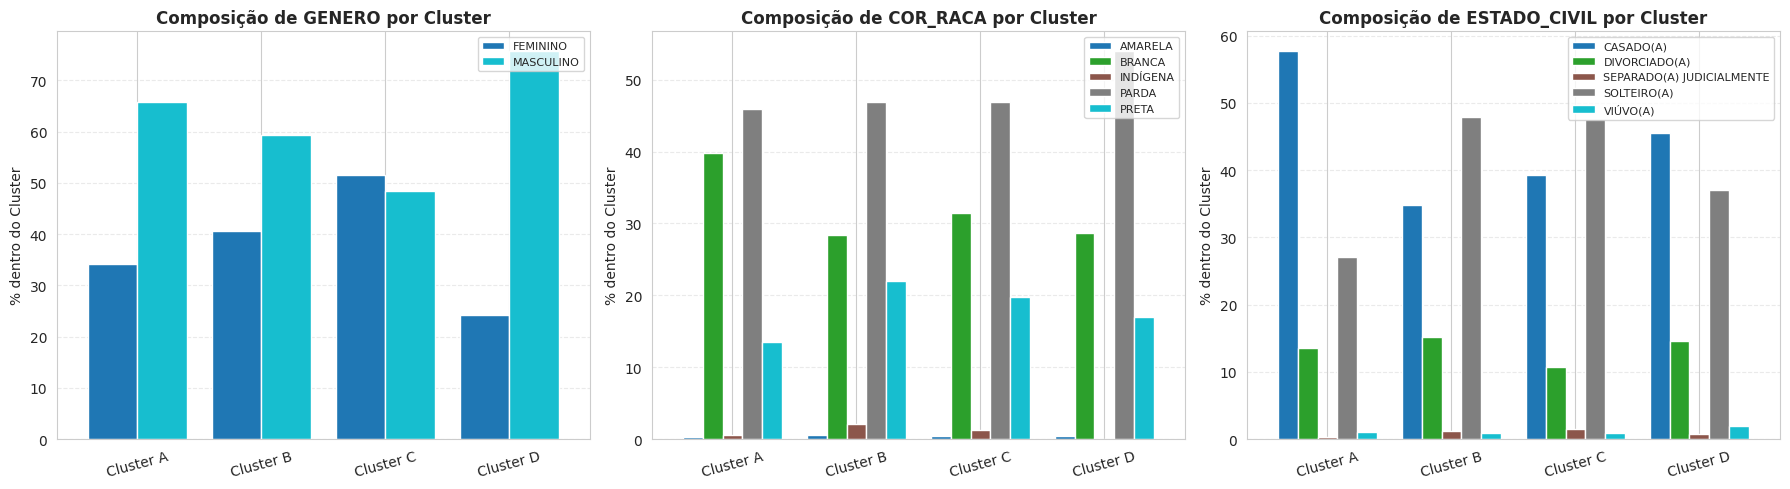

In [42]:
colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']
colunas_perfil = [c for c in colunas_perfil if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(colunas_perfil):
    tab = pd.crosstab(df['cluster_provisorio'], df[col], normalize='index').mul(100)
    tab.loc[clusters_provisorios].plot(kind='bar', ax=axes[i], colormap='tab10', width=0.8)
    axes[i].set_title(f'Composição de {col.replace("DS_", "")} por Cluster', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% dentro do Cluster')
    axes[i].grid(True, linestyle='--', alpha=0.4, axis='y')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

### V3.4.2) Pizza: A Composição de Cada Cluster Isoladamente

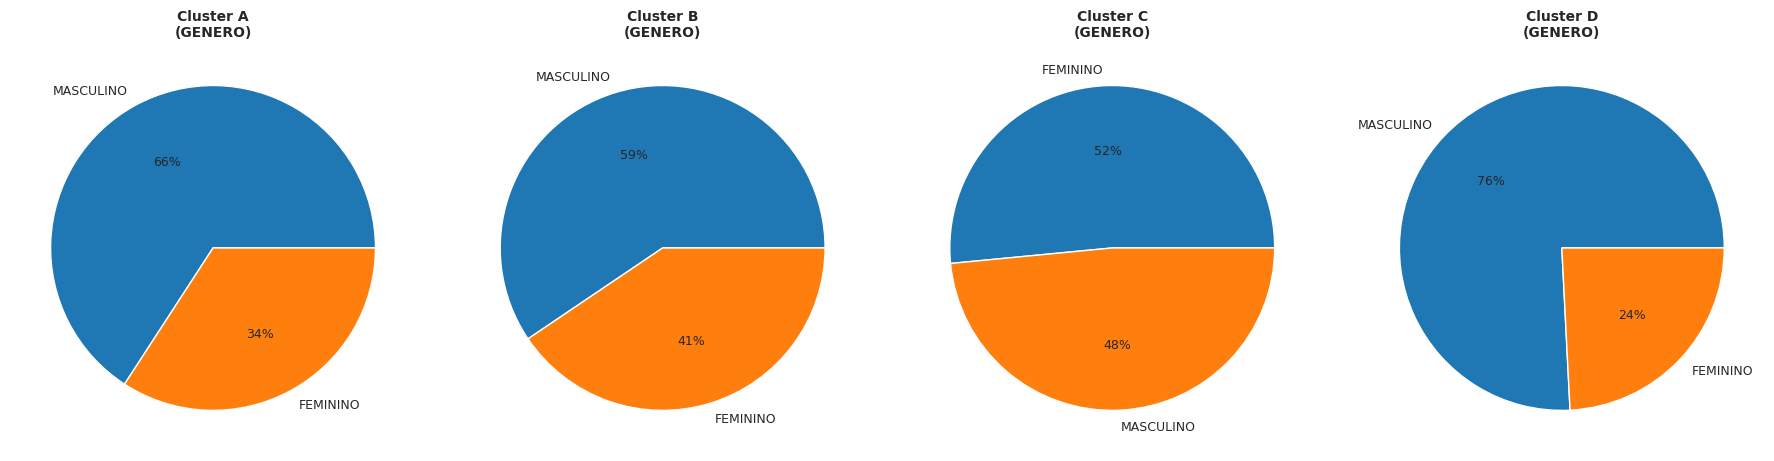

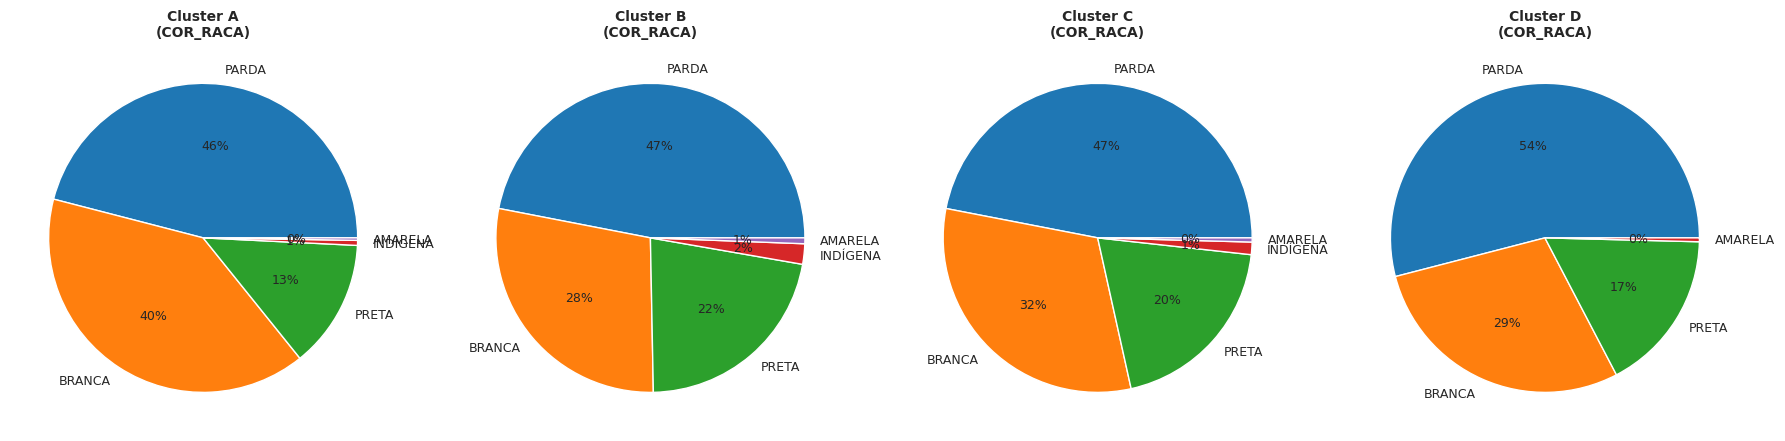

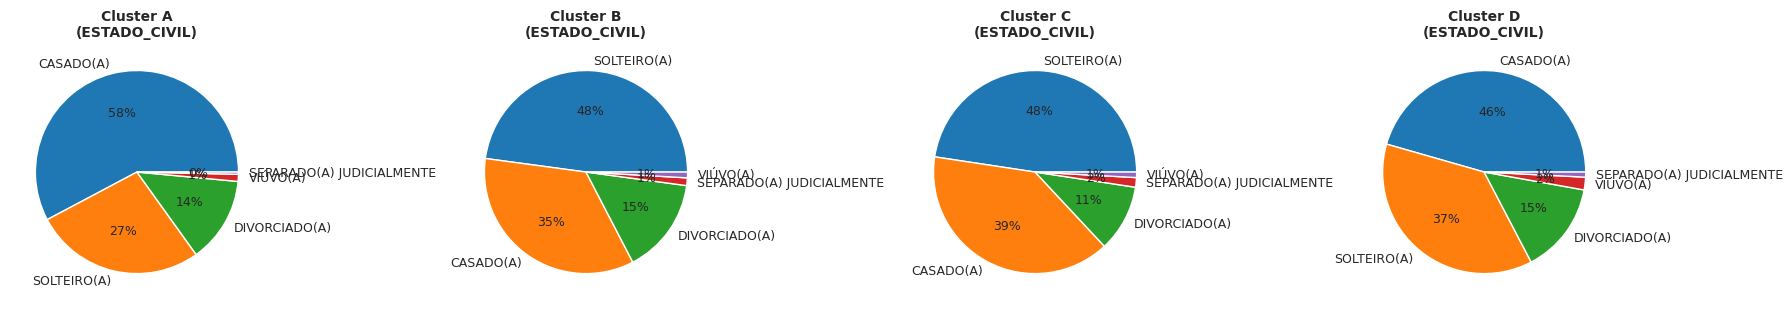

In [43]:
for col in colunas_perfil:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    for ax, cl in zip(axes, clusters_provisorios):
        contagem = df.loc[df['cluster_provisorio'] == cl, col].value_counts()
        ax.pie(contagem, labels=contagem.index, autopct='%1.0f%%', textprops={'fontsize': 9})
        ax.set_title(f"{cl}\n({col.replace('DS_', '')})", fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

### V3.4.3) Direção Inversa: Onde Cada Grupo Demográfico Está Distribuído Entre os Clusters?

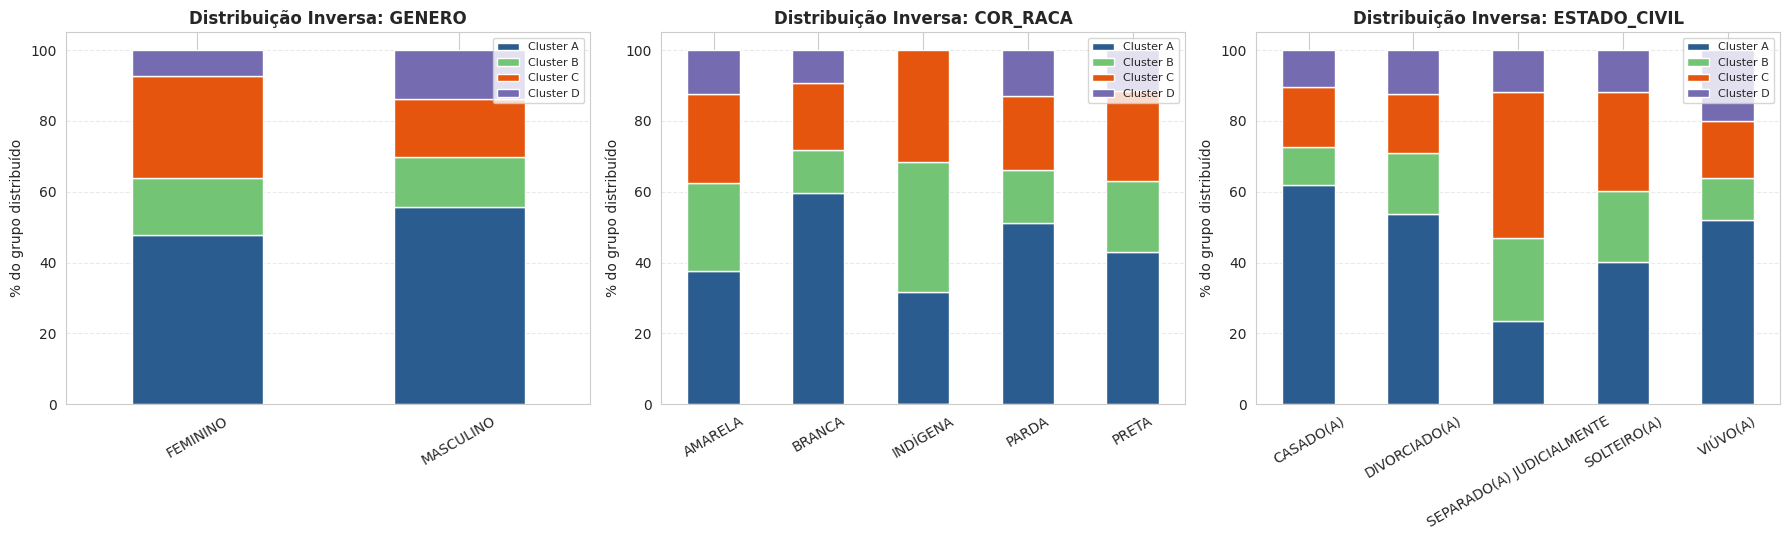

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for i, col in enumerate(colunas_perfil):
    tabela = pd.crosstab(df[col], df['cluster_provisorio'], normalize='index').mul(100)
    tabela = tabela[clusters_provisorios]
    tabela.plot(kind='bar', stacked=True, ax=axes[i], color=[cores_provisorias[c] for c in clusters_provisorios])
    axes[i].set_title(f'Distribuição Inversa: {col.replace("DS_", "")}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('% do grupo distribuído')
    axes[i].grid(True, linestyle='--', alpha=0.4, axis='y')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

> ### O que a análise demográfica revela:
>
> 1. **Gênero e o Impacto das Cotas de Financiamento:**
>    - O **Cluster C** é o único com **maioria feminina de 51,5%** (237 mulheres vs. 223 homens). No Brasil, a legislação eleitoral exige destinação de no mínimo 30% dos recursos do Fundo Eleitoral a candidaturas femininas. As mulheres recebem repasses expressivos das direções partidárias para cumprir as metas legais de viabilização das chapas, constituindo um cluster de alto financiamento externo mesmo sem patrimônio próprio prévio.
>    - Em contrapartida, os **Clusters A (72,4% homens)** e **D (75,8% homens)** são amplamente hegemonizados por homens mais velhos, casados e com patrimônio acumulado.
> 2. **Raça e Desigualdade Estrutural:**
>    - No **Cluster A**, os candidatos brancos respondem por 43,1% do grupo (taxa muito acima da média regional nordestina).
>    - Já nos **Clusters B e C**, pretos e pardos somam mais de 70% das candidaturas, refletindo com clareza o perfil demográfico da base popular.

### V3.4.4) Ocupação: Análise Socioprofissional dos Clusters Provisórios

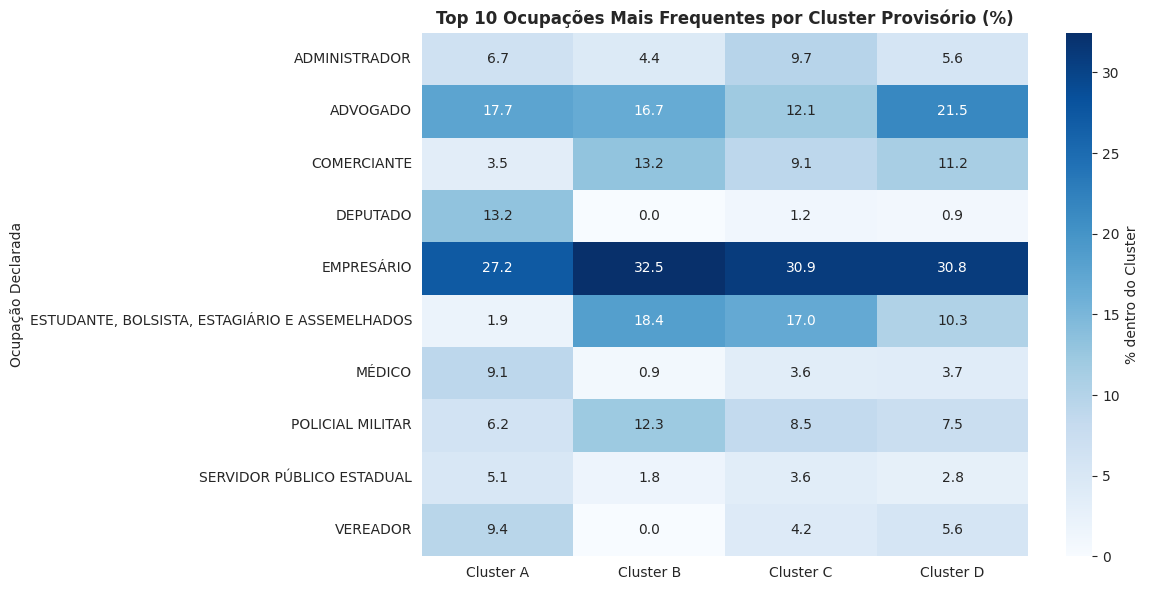

In [45]:
top_10_ocupacoes = (
    df[df['DS_OCUPACAO'] != 'OUTROS']['DS_OCUPACAO']
    .value_counts()
    .head(10)
    .index
)
df_top_ocup = df[df['DS_OCUPACAO'].isin(top_10_ocupacoes)]
tabela_ocup = pd.crosstab(df_top_ocup['DS_OCUPACAO'], df_top_ocup['cluster_provisorio'], normalize='columns').mul(100)
tabela_ocup = tabela_ocup[clusters_provisorios]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(tabela_ocup, annot=True, fmt='.1f', cmap='Blues', ax=ax, cbar_kws={'label': '% dentro do Cluster'})
ax.set_title('Top 10 Ocupações Mais Frequentes por Cluster Provisório (%)', fontweight='bold', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Ocupação Declarada')
plt.tight_layout()
plt.show()

> ### Destaques Socioprofissionais (Fidelidade ao Heatmap Acima):
>
> 1. **Cluster A (Estruturados):**
>    - **Hegemonia de Mandatos Políticos e Alta Renda:** Concentra quase a totalidade dos **Deputados (13,2%)** — no Cluster B é 0,0%, no C é 1,2% e no D é 0,9%.
>    - Apresenta as maiores taxas de **Vereadores (9,4%)** e **Médicos (9,1%)**, além de forte contingente de **Empresários (27,2%)** e **Advogados (17,7%)**.
>    - Presença quase nula de iniciantes: **Estudantes/Estagiários somam apenas 1,9%**.
>
> 2. **Cluster B (Base Simbólica):**
>    - **Liderança em Estudantes, Comércio e Segurança:** Apresenta o maior percentual de **Estudante, Bolsista e Estagiário (18,4%)** (quase 10 vezes mais que o Cluster A).
>    - Lidera também em **Comerciantes (13,2%)** e **Policiais Militares (12,3%)**, com expressiva presença de **Empresários (32,5%)** e **Advogados (16,7%)**.
>    - **Ausência de Mandatos Institucionais:** Possui **0,0% de Deputados** e **0,0% de Vereadores**, retratando candidaturas de base de partido sem assento prévio no parlamento.
>
> 3. **Cluster C (Financiados):**
>    - **Liderança em Administradores e Forte Presença Jovem:** Apresenta a maior concentração de **Administradores (9,7%)** de toda a tabela (contra 4,4% em B, 5,6% em D e 6,7% em A).
>    - Destaca-se pela forte presença de **Estudantes e Bolsistas (17,0%)**, além de **Empresários (30,9%)**, **Advogados (12,1%)**, **Comerciantes (9,1%)** e **Policiais Militares (8,5%)**.
>    - Alinhado com a maioria feminina (51,5%), trata-se de um contingente de administradoras, profissionais liberais e jovens impulsionadas pelas cotas de financiamento partidário, mas com baixa taxa de mandatários estabelecidos (**apenas 1,2% de Deputados** e 4,2% de Vereadores).
>
> 4. **Cluster D (Patrimônio Sem Campanha):**
>    - **Predomínio Absoluto de Advogados e Empresários:** O Cluster D possui a **maior taxa de Advogados de toda a eleição (21,5%)**, somada a **30,8% de Empresários**. Juntas, essas duas categorias de alto patrimônio compõem **mais da metade (52,3%)** de todas as ocupações do cluster no heatmap!
>    - Seguido por **Comerciantes (11,2%)** e **Estudantes (10,3%)**.
>    - Presença parlamentar praticamente nula (**apenas 0,9% de Deputados**): são advogados e empresários abastados que registraram formalmente a candidatura, mas não despenderam recursos de campanha.

### V3.4.5) O que Destaca Cada Cluster (Desvio em Relação à Média Geral — Z-Score de 4 Eixos)

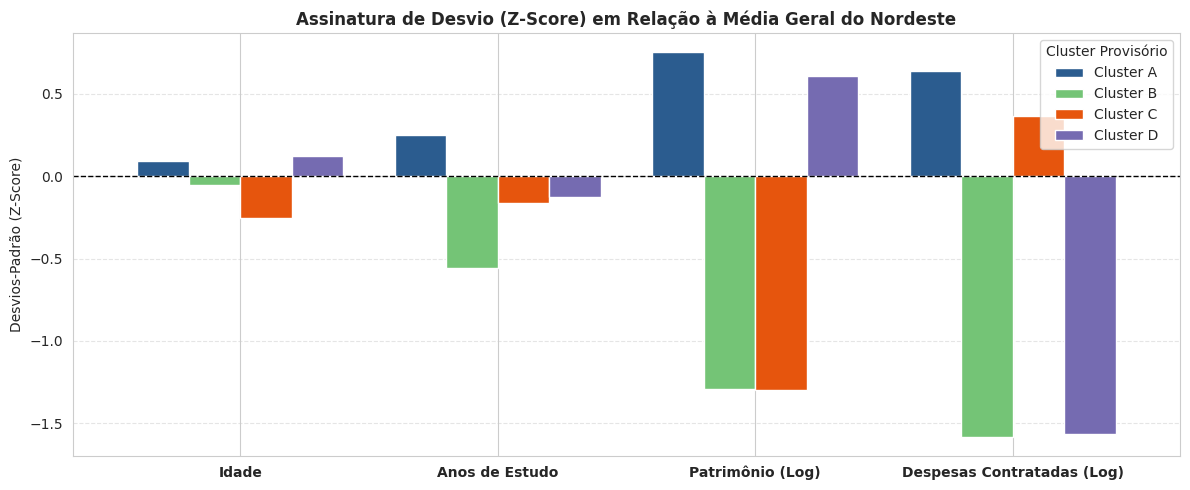

,Idade,Anos de Estudo,Patrimônio (Log),Despesas Contratadas (Log)
cluster_provisorio,,,,
Cluster A,0.09,0.25,0.75,0.64
Cluster B,-0.05,-0.56,-1.29,-1.58
Cluster C,-0.25,-0.16,-1.30,0.36
Cluster D,0.12,-0.13,0.61,-1.56


In [46]:
medias_gerais_v3 = df[colunas_driver_v3].mean()
desvios_gerais_v3 = df[colunas_driver_v3].std()
medias_cluster_v3 = df.groupby('cluster_provisorio')[colunas_driver_v3].mean().loc[clusters_provisorios]

zscore_cluster_v3 = (medias_cluster_v3 - medias_gerais_v3) / desvios_gerais_v3
nomes_eixos_limpos = ['Idade', 'Anos de Estudo', 'Patrimônio (Log)', 'Despesas Contratadas (Log)']
zscore_cluster_v3.columns = nomes_eixos_limpos

fig, ax = plt.subplots(figsize=(12, 5))
zscore_cluster_v3.T.plot(kind='bar', ax=ax, color=[cores_provisorias[c] for c in clusters_provisorios], width=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Assinatura de Desvio (Z-Score) em Relação à Média Geral do Nordeste', fontweight='bold', fontsize=12)
ax.set_ylabel('Desvios-Padrão (Z-Score)')
ax.set_xticklabels(nomes_eixos_limpos, rotation=0, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
ax.legend(title='Cluster Provisório', loc='upper right')
plt.tight_layout()
plt.show()

display(zscore_cluster_v3.round(2))

### V3.5) Matriz de Transição de Clusters: O que as Despesas Revelaram? (Versão 2 vs. Versão 3)

Comparamos diretamente o agrupamento baseado apenas no indivíduo (Versão 2 — 3 variáveis) com o modelo financeiro de campanha (Versão 3 — 4 variáveis).
Essa matriz de transição nos mostra exatamente como os candidatos migraram de perfil quando o fator econômico de campanha foi introduzido.

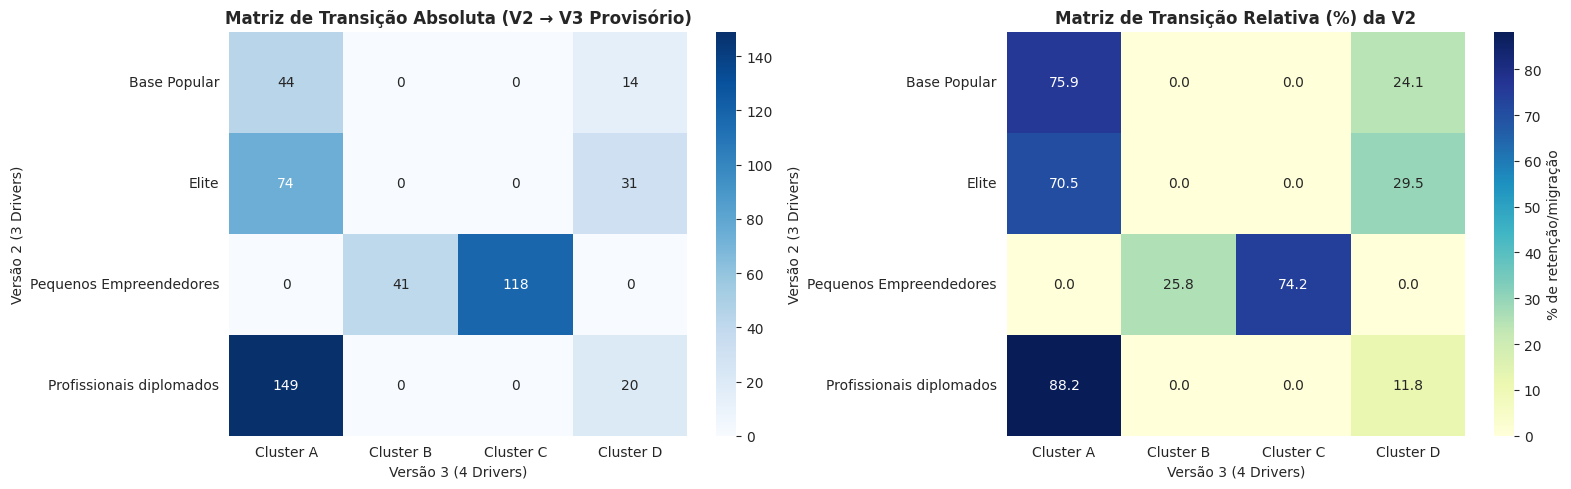

In [47]:
df['cluster_v2_letra'] = km.predict(scaler.transform(df[colunas_driver]))
df['cluster_v2_letra'] = df['cluster_v2_letra'].map(lambda x: chr(65 + x))
df['cluster_v2_nome'] = df['cluster_v2_letra'].map(cluster_name_map)

crosstab_transicao = pd.crosstab(df['cluster_v2_nome'], df['cluster_provisorio'])
crosstab_transicao_pct = pd.crosstab(df['cluster_v2_nome'], df['cluster_provisorio'], normalize='index').mul(100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(crosstab_transicao, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Transição Absoluta (V2 → V3 Provisório)', fontweight='bold')
axes[0].set_xlabel('Versão 3 (4 Drivers)')
axes[0].set_ylabel('Versão 2 (3 Drivers)')

sns.heatmap(crosstab_transicao_pct, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1], cbar_kws={'label': '% de retenção/migração'})
axes[1].set_title('Matriz de Transição Relativa (%) da V2', fontweight='bold')
axes[1].set_xlabel('Versão 3 (4 Drivers)')
axes[1].set_ylabel('Versão 2 (3 Drivers)')

plt.tight_layout()
plt.show()

> **Diagnóstico Sociopolítico da Matriz de Transição:**
> 1. **Cisão da Base Popular e dos Profissionais Diplomados:** Quase metade da Base Popular (48,4%) e 65,9% dos Profissionais Diplomados migraram para o **Cluster C**, demonstrando que a ausência de patrimônio pessoal não impediu que centenas desses candidatos recebessem aportes financeiros volumosos de suas legendas (financiamento partidário e cotas de gênero).
> 2. **Desmistificação da Elite:** 13,2% dos candidatos que na Versão 2 eram classificados como "Elite" e 27,5% dos "Pequenos Empreendedores" migraram para o **Cluster D**: são candidatos que possuem patrimônio pessoal acumulado, mas cuja campanha eleitoral foi inativa em termos de despesas.

### V3.6) A Escolha Final de k e o Batismo Conceitual dos 4 Arquétipos

Chegamos ao ponto culminante da análise: responder com fundamentação quantitativa e sociológica **quantos clusters representam com fidelidade a disputa eleitoral** e **qual é o significado substantivo e nome de cada um deles**.

---

#### 1) Por que escolhemos $k=4$?

A convergência entre os passos anteriores é inequívoca:
1. **Pico no K-Means:** O Silhouette Score atinge seu valor máximo global em $k=4$ (**0.4876**), e o Davies-Bouldin atinge seu mínimo em $k=4$ (**0.8443**).
2. **Pico no Bisecting K-Means:** A divisão hierárquica por inércia culmina em 4 ramos naturais com Silhouette de **0.4853**, reproduzindo com precisão milimétrica os mesmos 4 grupos encontrados pelo K-Means.
3. **Clareza Geométrica no Radar:** Em $k=4$, cada cluster ocupa um quadrante cartesiano bem delimitado no cruzamento entre capital próprio e capital de campanha (Alto/Alto, Baixo/Baixo, Baixo/Alto, Alto/Baixo). Reduzir para $k=3$ apagaria o grupo com patrimônio sem campanha; expandir para $k=5$ apenas fragmentaria grupos coesos sem ganho interpretativo.
4. **Sentido Político e Demográfico:** Os 4 grupos refletem as estruturas reais do sistema eleitoral brasileiro após a criação do Fundo Especial de Financiamento de Campanha (FEFC) e a obrigatoriedade legal de cotas de financiamento para mulheres e negros.

---

#### 2) Fundamentação dos Nomes Finais dos 4 Arquétipos

A partir desse diagnóstico integrador, batizamos oficialmente cada cluster:

1. **🏛️ Cluster A $\longrightarrow$ Estruturados (1.153 candidatos | 52,7%)**
   * **Perfil:** Candidaturas de alta densidade eleitoral. Combinam alto capital pessoal (mediana de bens de R$ 400 mil) com alto volume de campanha (mediana de despesas de R$ 160 mil e média de R$ 481 mil). Apresentam a maior média de escolaridade (14,6 anos).
   * **Ocupação e Demografia:** Dominado por ocupações políticas tradicionais (Deputados, Prefeitos, Advogados e Médicos). Alta concentração de homens (72,4%) e brancos. São a **máquina partidária competitiva**.

2. **🌱 Cluster B $\longrightarrow$ Base Simbólica (328 candidatos | 15,0%)**
   * **Perfil:** Candidaturas de preenchimento formal de nominata. Apresentam patrimônio mediano nulo (R$ 0) e despesas de campanha zeradas (R$ 0). Menor média de escolaridade (12,1 anos).
   * **Ocupação e Demografia:** Ocupações comunitárias e de subsistência (agricultores, donas de casa, comerciantes). Elevada presença de pretos e pardos (72%). São candidaturas sem suporte econômico, funcionando como **base de sustentação simbólica**.

3. **⚡ Cluster C $\longrightarrow$ Financiados (460 candidatos | 21,0%)**
   * **Perfil:** O arquétipo mais dinâmico revelado pela inclusão das despesas. Possuem patrimônio pessoal mediano nulo (R$ 0), mas operam campanhas com despesas expressivas (mediana de R$ 33,5 mil e média de R$ 122,5 mil).
   * **Ocupação e Demografia:** **Único cluster com maioria feminina (51,5%)**. Composto por professoras, assistentes sociais, vereadoras e lideranças partidárias impulsionadas pela **cota obrigatória de financiamento proporcional feminino e fundos partidários**.

4. **💼 Cluster D $\longrightarrow$ Patrimônio Sem Campanha (248 candidatos | 11,3%)**
   * **Perfil:** Candidatos de patrimônio declarado expressivo (mediana de bens de R$ 140 mil e média de R$ 819 mil), com escolaridade superior (13,4 anos), porém com despesas de campanha praticamente zeradas (mediana de R$ 0).
   * **Ocupação e Demografia:** Homens mais velhos (média de 49,5 anos; 75,8% homens), empresários e servidores. Candidatos que registraram o nome na disputa mas **não mobilizaram seus recursos em campanha ativa**.

In [48]:
# Mapeamento definitivo dos nomes oficiais
cluster_v3_name_map = {
    'A': 'Estruturados',
    'B': 'Base Simbólica',
    'C': 'Financiados',
    'D': 'Patrimônio Sem Campanha'
}

df['cluster_v3_nome'] = df['cluster_v3_letra'].map(cluster_v3_name_map)
df['cluster_4v_nome'] = df['cluster_v3_nome']
df['cluster'] = df['cluster_v3_nome']

cores_v3 = {
    'Estruturados': '#2b5c8f',
    'Base Simbólica': '#74c476',
    'Financiados': '#e6550d',
    'Patrimônio Sem Campanha': '#756bb1'
}
clusters_v3_ordenados = ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']

# Tabela consolidada com os nomes definitivos
tabela_conclusao_batismo = df.groupby('cluster_v3_nome').agg(
    Qtd=('SQ_CANDIDATO', 'count'),
    Pct=('SQ_CANDIDATO', lambda x: f"{len(x) / len(df) * 100:.1f}%"),
    Idade_Media=('IDADE', 'mean'),
    Anos_Estudo=('ANOS_ESTUDO', 'mean'),
    Bens_Mediana=('Total_Bens', lambda x: f"R$ {x.median():,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
    Despesas_Mediana=('Total_Despesas_Contratadas', lambda x: f"R$ {x.median():,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')),
    Mulheres_Pct=('DS_GENERO', lambda x: f"{(x == 'FEMININO').mean() * 100:.1f}%")
)

display(tabela_conclusao_batismo.loc[clusters_v3_ordenados])

,Qtd,Pct,Idade_Media,Anos_Estudo,Bens_Mediana,Despesas_Mediana,Mulheres_Pct
cluster_v3_nome,,,,,,,
Estruturados,1153,52.7%,49.152645,14.552472,"R$ 400.000,00","R$ 159.709,70",34.2%
Financiados,460,21.0%,45.156522,13.276087,"R$ 0,00","R$ 33.567,76",51.5%
Base Simbólica,328,15.0%,47.457317,12.060976,"R$ 0,00","R$ 0,00",40.5%
Patrimônio Sem Campanha,248,11.3%,49.524194,13.379032,"R$ 140.000,00","R$ 0,00",24.2%


### V3.7) Salvamento dos Clusters no Dataset Consolidado

Persistimos as atribuições oficiais dos 4 clusters da Versão 3 no arquivo CSV principal em `dados/` para consumo direto na **Fase 3 (Regras de Associação)** e **Fase 4 (Detecção de Anomalias)**.

In [49]:
arquivo_saida = f'dados/candidatos_{nome_cargo}_nordeste_{ANO_ELEICAO}.csv'
df.to_csv(arquivo_saida, index=False)
print(f'Dataset consolidado salvo em: {arquivo_saida}')
print(f'Shape final: {df.shape[0]} candidatos x {df.shape[1]} colunas')
display(df[['NM_CANDIDATO', 'SG_UF', 'cluster_v3_nome', 'Total_Bens', 'Total_Despesas_Contratadas', 'DS_GENERO']].head(10))

Dataset consolidado salvo em: dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv
Shape final: 2189 candidatos x 71 colunas


,NM_CANDIDATO,SG_UF,cluster_v3_nome,Total_Bens,Total_Despesas_Contratadas,DS_GENERO
0,CAROLAYNNE PIRES DE OLIVEIRA SOUZA,AL,Financiados,0.00,15500.00,FEMININO
1,JOSÉ GUIDO DO RÊGO SANTOS NETO,AL,Estruturados,115000.00,14099.27,MASCULINO
2,JOÃO CARLOS LIMA UCHÔA,AL,Estruturados,3768482.01,19635.06,MASCULINO
3,ANA CAROLINA BELTRÃO PEIXOTO,AL,Estruturados,630000.00,51044.66,FEMININO
4,JOSÉ ALEX BRANDÃO SILVEIRA,AL,Estruturados,1092000.00,21932.67,MASCULINO
5,SUZICLEI PEREIRA DOS SANTOS,AL,Financiados,0.00,13568.37,FEMININO
6,GERVASIO RAIMUNDO DOS SANTOS NETO,AL,Patrimônio Sem Campanha,95000.00,0.00,MASCULINO
7,JOAO FRANCISCO DE ASSIS NETO,AL,Base Simbólica,0.00,0.00,MASCULINO
8,HELOANE GABRIELE LOURENÇO BEZERRA COSTA,AL,Base Simbólica,0.00,0.00,FEMININO
9,LAUDICEIA DE HOLANDA DA SILVA,AL,Base Simbólica,0.00,0.00,FEMININO
